# Filtering TM/TR CDF plot (stencil 0616 dsub)

Full run on 3 nodes with fixed stencil C (commit 62f367f+935386e). Bug fixes: ARM fence, MPI_Init order, NPRECALC prewarm, ra>lower guard.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
DATE_BASE = "20260616"
HOST_ORDER = ["cgnr6760pn2", "camd9554n1", "c920bn3"]
SHUFFLE_SELECT = "shuffle2"

# Previous 0614/root examples, kept for audit and intentionally not used:
# /astrum/home/hpchzy/code/data/20260614/c920bn3/output_filt/full-stencil-0614-c920bn3/shuffle0
# Reason: 0614 stencil harness used INSITU_SUB_ASM/output_filt and did not have tvkern-style dsub/effective NSPV/run-log handling.

RUN_ROOT_OVERRIDES = {}


def latest_run_root(host, shuffle_select=SHUFFLE_SELECT):
    if host in RUN_ROOT_OVERRIDES:
        return RUN_ROOT_OVERRIDES[host]
    base = Path(f"/astrum/home/hpchzy/code/data/{DATE_BASE}/{host}/output_stencil_filt_dsub")
    stamps = sorted([p for p in base.iterdir() if p.is_dir()]) if base.exists() else []
    for stamp in reversed(stamps):
        root = stamp / shuffle_select
        if root.exists():
            return root
    return base / "REPLACE_TIMESTAMP-stencil-dsub" / shuffle_select

RUN_ROOTS = [latest_run_root(host, SHUFFLE_SELECT).parent for host in HOST_ORDER]
DATA_FOLDERS = [latest_run_root(host, SHUFFLE_SELECT) for host in HOST_ORDER]
SHUFFLE_LABEL = "_".join(f"{host}-{Path(root).name}" for host, root in zip(HOST_ORDER, DATA_FOLDERS))

QUANTILE_DROP = 0.99
SAVE_FIG = True
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub')

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
    'cntvct': '#00a6d6',
    'cntvcto': '#e377c2',
}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
    'cntvct': 'CNTVCT',
    'cntvcto': 'CNTVCTO',
}

KERNEL_LABELS = {
    'jacobi2d5p': '2D 5-Point Jacobi Stencil',
    'tl_f90_cg_calc_w': 'TL F90 CG',
    'gs2d5p': '2D 5-Point Gauss-Seidel',
}

HOST_LABELS = {
    "cgnr6760pn2": "Intel Xeon 6760P",
    "camd9554n1": "AMD EPYC 9554",
    "camd9554n2": "AMD EPYC 9554",
    "c920bn3": "Kunpeng 920B",
}

for root in DATA_FOLDERS:
    print(root)
print("host_order:", HOST_ORDER)
print("shuffle_label:", SHUFFLE_LABEL)


/astrum/home/hpchzy/code/data/20260616/cgnr6760pn2/output_stencil_filt_dsub/20260616-134358-stencil-dsub/shuffle2
/astrum/home/hpchzy/code/data/20260616/camd9554n1/output_stencil_filt_dsub/20260616-130741-stencil-dsub/shuffle2
/astrum/home/hpchzy/code/data/20260616/c920bn3/output_stencil_filt_dsub/20260616-123531-stencil-dsub/shuffle2
host_order: ['cgnr6760pn2', 'camd9554n1', 'c920bn3']
shuffle_label: cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2


In [3]:
def parse_filt_dir(path):
    m = re.match(r'(?P<prefix>.+)_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<nsampRatio>[\d.]+)_nsamp(?P<nsamp>\d+)_filt$', path.name)
    if not m:
        return None
    d = m.groupdict()
    prefix = d.pop('prefix')
    kernel = None
    timer = None
    for candidate in sorted(TIMER_LABELS, key=len, reverse=True):
        suffix = f'_{candidate}'
        if prefix.endswith(suffix):
            kernel = prefix[:-len(suffix)]
            timer = candidate
            break
    if not kernel or not timer:
        return None
    d['kernel'] = kernel
    d['timer'] = timer
    d['np'] = int(d['np'])
    d['size'] = int(d['size'])
    d['nsamp'] = int(d['nsamp'])
    d['nsampRatio'] = float(d['nsampRatio'])
    return d


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid', 'cntvct', 'cntvcto']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    return df['ns'].to_numpy()


def read_tr(tr_hist_file):
    """Read tr_hist.csv as piecewise-linear CDF.

    Format: (left_edge, prob) per row; bin [t_i, t_{i+1}) has probability prob_i;
    last row is sentinel with prob=0 (right boundary).
    Returns df with cdf[i] = cumulative probability at LEFT edge of bin i,
    so plotting ns vs cdf gives a diagonal piecewise-linear CDF (not step function).
    """
    df = pd.read_csv(tr_hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df.sort_values('ns', inplace=True)
    total = df['prob'].sum()
    if total > 0:
        df['prob'] = df['prob'] / total
    cs = df['prob'].cumsum()
    # Keep bins whose LEFT edge starts below QUANTILE_DROP, plus one right-boundary row.
    left_cdf = cs.shift(1, fill_value=0.0)
    keep = left_cdf < QUANTILE_DROP
    if keep.any():
        iloc_last = df.index.get_loc(keep[keep].index[-1])
        if iloc_last + 1 < len(df):
            keep.iloc[iloc_last + 1] = True
    df = df[keep].copy()
    # cdf[i] = CDF at left edge of bin i = sum of probs of all PREVIOUS bins
    df['cdf'] = df['prob'].cumsum().shift(1, fill_value=0.0)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'shuffle': data_folder.name, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)

entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
print(f'entries: {len(entries)}')
entries.sort_values(['host', 'kernel', 'np', 'size', 'timer']).head(20)
entries = entries[(entries['timer'] != 'tsc_native') & (entries['timer'] != 'cntvct')]
# entries = entries[(entries['timer'] != 'papi') & (entries['timer'] != 'cgt')]


entries: 324


# ER/EP/Wasserstein

In [4]:
from scipy.stats import wasserstein_distance


def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def clean_hist_for_wd(hist_file, ns_col='ns', pr_col='pr'):
    df = pd.read_csv(hist_file, header=None, names=[ns_col, pr_col])
    df[ns_col] = pd.to_numeric(df[ns_col], errors='coerce')
    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')
    df = df[np.isfinite(df[ns_col]) & np.isfinite(df[pr_col])].copy()
    df = df[df[pr_col] > 0]
    if df.empty or df[pr_col].sum() <= 0:
        return None
    return df


def wd_to_min(hist_file):
    df = clean_hist_for_wd(hist_file)
    if df is None:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['pr'].to_numpy(dtype=float)
    return wasserstein_distance(ns, np.array([ns.min()]), pr, np.array([1.0]))


def read_hist_for_sampling(hist_file):
    """Read (lb, pr) histogram into (lb, rb, pr) DataFrame for quantile sampling."""
    try:
        tmp = pd.read_csv(hist_file, header=None, names=['lb', 'pr'])
    except Exception:
        return None
    tmp['lb'] = pd.to_numeric(tmp['lb'], errors='coerce')
    tmp['pr'] = pd.to_numeric(tmp['pr'], errors='coerce').fillna(0.0)
    tmp = tmp.dropna(subset=['lb']).reset_index(drop=True)
    m = ~np.isclose(tmp['pr'], 0)
    if not m.any():
        return None
    last_nz = int(np.where(m)[0][-1])
    if last_nz + 1 >= len(tmp):
        return None
    tmp = tmp.iloc[:last_nz + 2].copy()
    tmp['rb'] = tmp['lb'].shift(-1)
    tmp['lb'] = tmp['lb'].astype(np.float64)
    tmp = tmp[['lb', 'rb', 'pr']].iloc[:-1].dropna()
    return tmp if not tmp.empty else None


def sample_from_bins_quantile(tmp_df, n=1000):
    lb = tmp_df['lb'].to_numpy()
    rb = tmp_df['rb'].to_numpy()
    pr = tmp_df['pr'].to_numpy()
    pr = pr / pr.sum()
    p0 = np.r_[0, np.cumsum(pr)]
    q = (np.arange(n) + 0.5) / n
    idx = np.searchsorted(p0[1:], q, side='right')
    local_t = (q - p0[idx]) / pr[idx]
    return lb[idx] + local_t * (rb[idx] - lb[idx])


SEQ_N = 1000

summary_rows = []
for idx, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    ep = read_float_file(filt_folder / 'ep.out')
    er = read_float_file(filt_folder / 'er.out')
    wd = read_float_file(filt_folder / 'wd.out')
    tm_wd = wd_to_min(filt_folder / 'tm_hist.csv')
    tr_wd = wd_to_min(filt_folder / 'tr_hist.csv')
    if not np.isfinite(tm_wd) or not np.isfinite(tr_wd):
        print(f"warning: invalid histogram for Wasserstein: {filt_folder.name} tm_wd={tm_wd} tr_wd={tr_wd}")
    _tr_h = read_hist_for_sampling(filt_folder / 'tr_hist.csv')
    _tm_h = read_hist_for_sampling(filt_folder / 'tm_hist.csv')
    tr_seq = sample_from_bins_quantile(_tr_h, SEQ_N) if _tr_h is not None else None
    tm_seq = sample_from_bins_quantile(_tm_h, SEQ_N) if _tm_h is not None else None
    summary_rows.append({**row.to_dict(), 'ep': ep, 'er': er, 'wd': wd, 'tm_wd': tm_wd, 'tr_wd': tr_wd, 'tr_seq': tr_seq, 'tm_seq': tm_seq})

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df.sort_values(['host', 'kernel', 'np', 'size', 'timer'], inplace=True)

df = df[~df['kernel'].str.contains('tsc')]

df[['host', 'kernel', 'timer', 'np', 'size', 'ep', 'er', 'wd', 'tm_wd', 'tr_wd']].head(20)  # tr_seq/tm_seq stored as object columns


,host,kernel,timer,np,size,ep,er,wd,tm_wd,tr_wd
185,c920bn3,gs2d5p,cgt,64,64,0.000000,0.009215,3.337688,0.000000,0.000000
191,c920bn3,gs2d5p,cntvcto,64,64,0.000000,0.008100,2.874372,0.000000,0.000000
197,c920bn3,gs2d5p,papi,64,64,0.013677,0.016334,8.059296,3.239257,3.239260
203,c920bn3,gs2d5p,papix6,64,64,0.006636,0.010912,5.445226,8.734259,8.734290
209,c920bn3,gs2d5p,wtime,64,64,0.000000,0.008885,3.234171,0.000000,0.000000
181,c920bn3,gs2d5p,cgt,64,128,0.000000,0.005209,3.728643,0.000000,0.000000
187,c920bn3,gs2d5p,cntvcto,64,128,0.003378,0.005948,4.214070,8.511100,8.511100
193,c920bn3,gs2d5p,papi,64,128,0.005982,0.006719,5.687437,6.338201,6.338200
199,c920bn3,gs2d5p,papix6,64,128,0.006855,0.005255,4.471357,10.764128,10.764130
205,c920bn3,gs2d5p,wtime,64,128,0.001246,0.006445,4.623116,7.330784,7.330790


In [5]:
df["timer_label"] = df["timer"].map(TIMER_LABELS).fillna(df["timer"])
df["kernel_label"] = df["kernel"].map(KERNEL_LABELS).fillna(df["kernel"])


/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_wd_ep_er_by_host.png


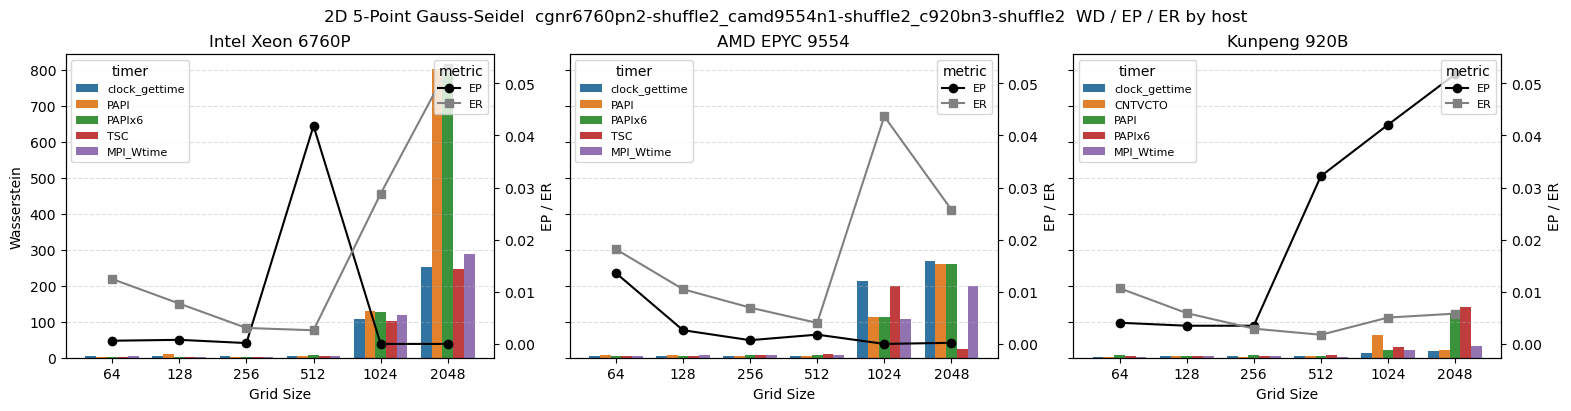

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/jacobi2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_wd_ep_er_by_host.png


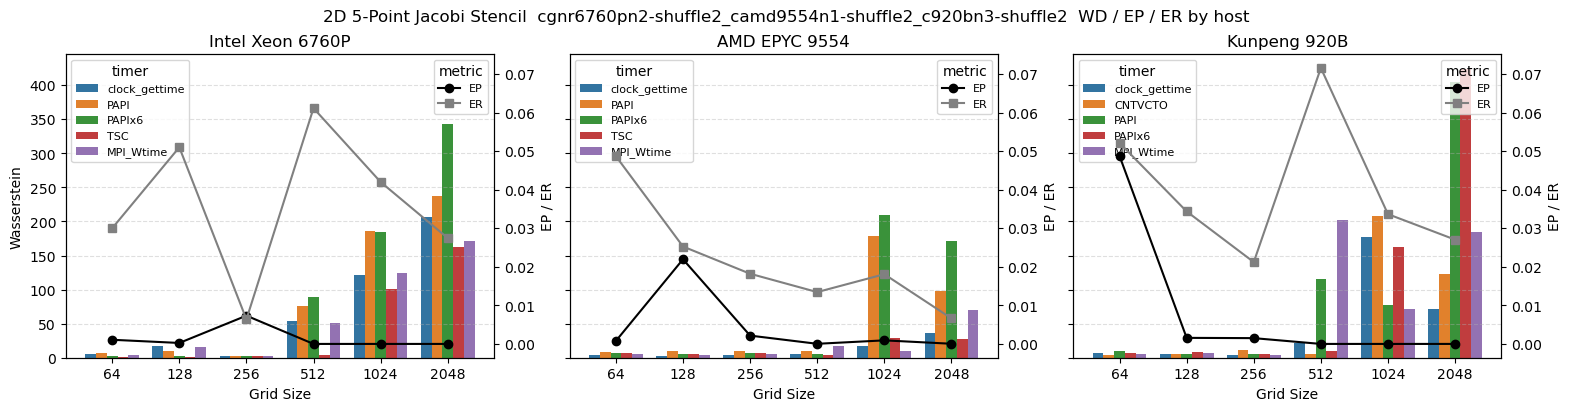

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_wd_ep_er_by_host.png


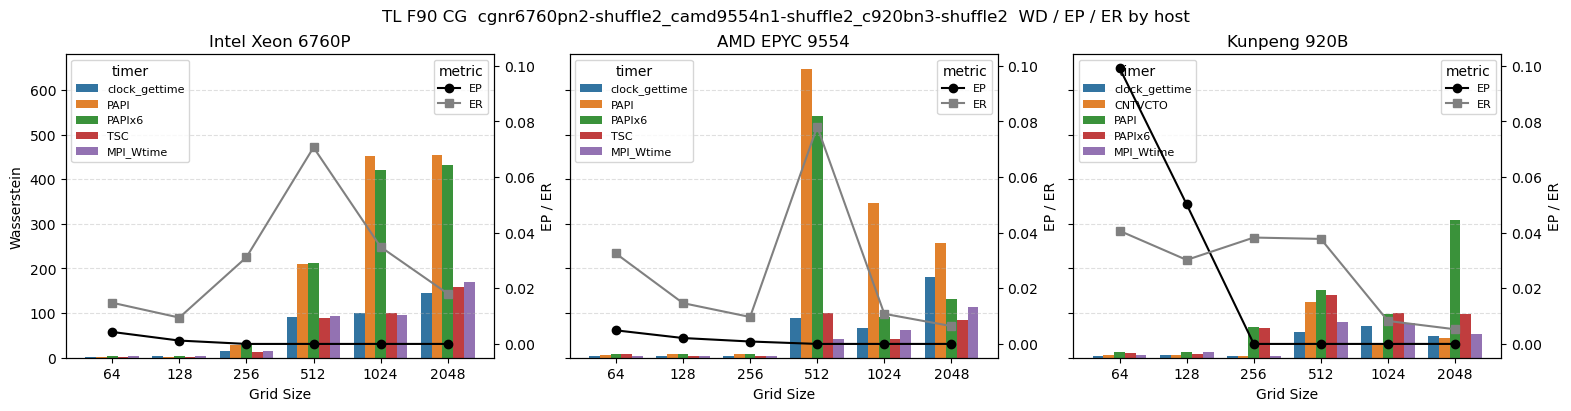

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metric_bar = 'wd'
line_metrics = ['ep', 'er']

plot_df = df.copy()
plot_df['timer_label'] = plot_df['timer'].map(TIMER_LABELS).fillna(plot_df['timer'])
plot_df['kernel_label'] = plot_df['kernel'].map(KERNEL_LABELS).fillna(plot_df['kernel'])
plot_df['size_str'] = plot_df['size'].astype(str)
size_order = [str(x) for x in sorted(plot_df['size'].unique())]
plot_df['size_str'] = pd.Categorical(plot_df['size_str'], categories=size_order, ordered=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]
kernels = sorted(plot_df['kernel'].dropna().unique())

for kernel in kernels:
    kernel_df = plot_df[plot_df['kernel'] == kernel].copy()
    if kernel_df.empty:
        continue

    fig, axes = plt.subplots(1, len(hosts), figsize=(5.2 * len(hosts), 4), sharey=True, constrained_layout=True)
    if len(hosts) == 1:
        axes = [axes]

    right_axes = []
    for ax1, host in zip(axes, hosts):
        host_df = kernel_df[kernel_df['host'] == host]
        host_label = HOST_LABELS.get(host, host)
        ax1.set_title(host_label)
        ax1.set_xlabel('Grid Size')
        ax1.set_ylabel('Wasserstein' if ax1 is axes[0] else '')
        ax1.grid(axis='y', linestyle='--', alpha=0.4)

        ax2 = ax1.twinx()
        right_axes.append(ax2)
        ax2.set_ylabel('EP / ER')

        if host_df.empty:
            ax1.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax1.transAxes)
            ax1.set_xticks([])
            ax2.set_yticks([])
            continue

        sns.barplot(data=host_df, x='size_str', y=metric_bar, hue='timer_label', ax=ax1)

        line_df = host_df.groupby(['size_str'], observed=True)[line_metrics].mean().reset_index()
        x_pos = range(len(line_df))
        ax2.plot(x_pos, line_df['ep'], marker='o', label='EP', color='black')
        ax2.plot(x_pos, line_df['er'], marker='s', label='ER', color='gray')
        ax2.set_xticks(list(x_pos))
        ax2.set_xticklabels(line_df['size_str'])

        ax1.legend(title='timer', fontsize=8, loc='upper left')
        ax2.legend(title='metric', fontsize=8, loc='upper right')

    left_lims = [ax.get_ylim() for ax in axes]
    right_lims = [ax.get_ylim() for ax in right_axes]
    left_ylim = (min(lo for lo, hi in left_lims), max(hi for lo, hi in left_lims))
    right_ylim = (min(lo for lo, hi in right_lims), max(hi for lo, hi in right_lims))
    for ax in axes:
        ax.set_ylim(left_ylim)
    for ax in right_axes:
        ax.set_ylim(right_ylim)

    kernel_label = kernel_df['kernel_label'].iloc[0]
    fig.suptitle(f'{kernel_label}  {SHUFFLE_LABEL}  {metric_bar.upper()} / EP / ER by host')

    if SAVE_FIG:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_wd_ep_er_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()


# Filt Plot

In [7]:
entries['nsamp'].unique()

array([ 4309,   531, 10214,  1045,  2071,   275,  4484,   707,  8908,
        1221,  2248,   451,  4538,   716,  9144,  1229,  2257,   459,
        4280,   526, 10074,  1039,  2064,   267,   532,  9933,  1046,
        2072,   276,  3812,   171,  8926,   310,   964,   101,  3628,
         358,  8717,   497,   889,   289,  3611,   367,  8692,   507,
         895,   298,  3169,   178,  8250,   328,   679,   103,  3784,
         174,  8874,   313,   894,   104,  7271,   288, 16472,   618,
        2013,   160,  7454,   476, 16651,   800,  2201,   348,  7481,
         488, 16678,   808,  2214,   355,  7227,   283, 16448,   606,
        2018,   156,  7298,   292, 16478,   620,  2026,   166,  4936,
         604, 12217,  1179,  2328,  5634,  1536, 11750,  2111,  3275,
        1241,  5852,  1753, 11735,  3492,  1458,  4919,   589, 11657,
        1164,  4983, 12246,  2329,  8041,   201, 19557,   342,   699,
         124,  7652,  1102, 18720,  1272,  1660,  1024,  7574,  1319,
       18488,  1491,

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size64_ratio0.5_tm_tr_by_host.png


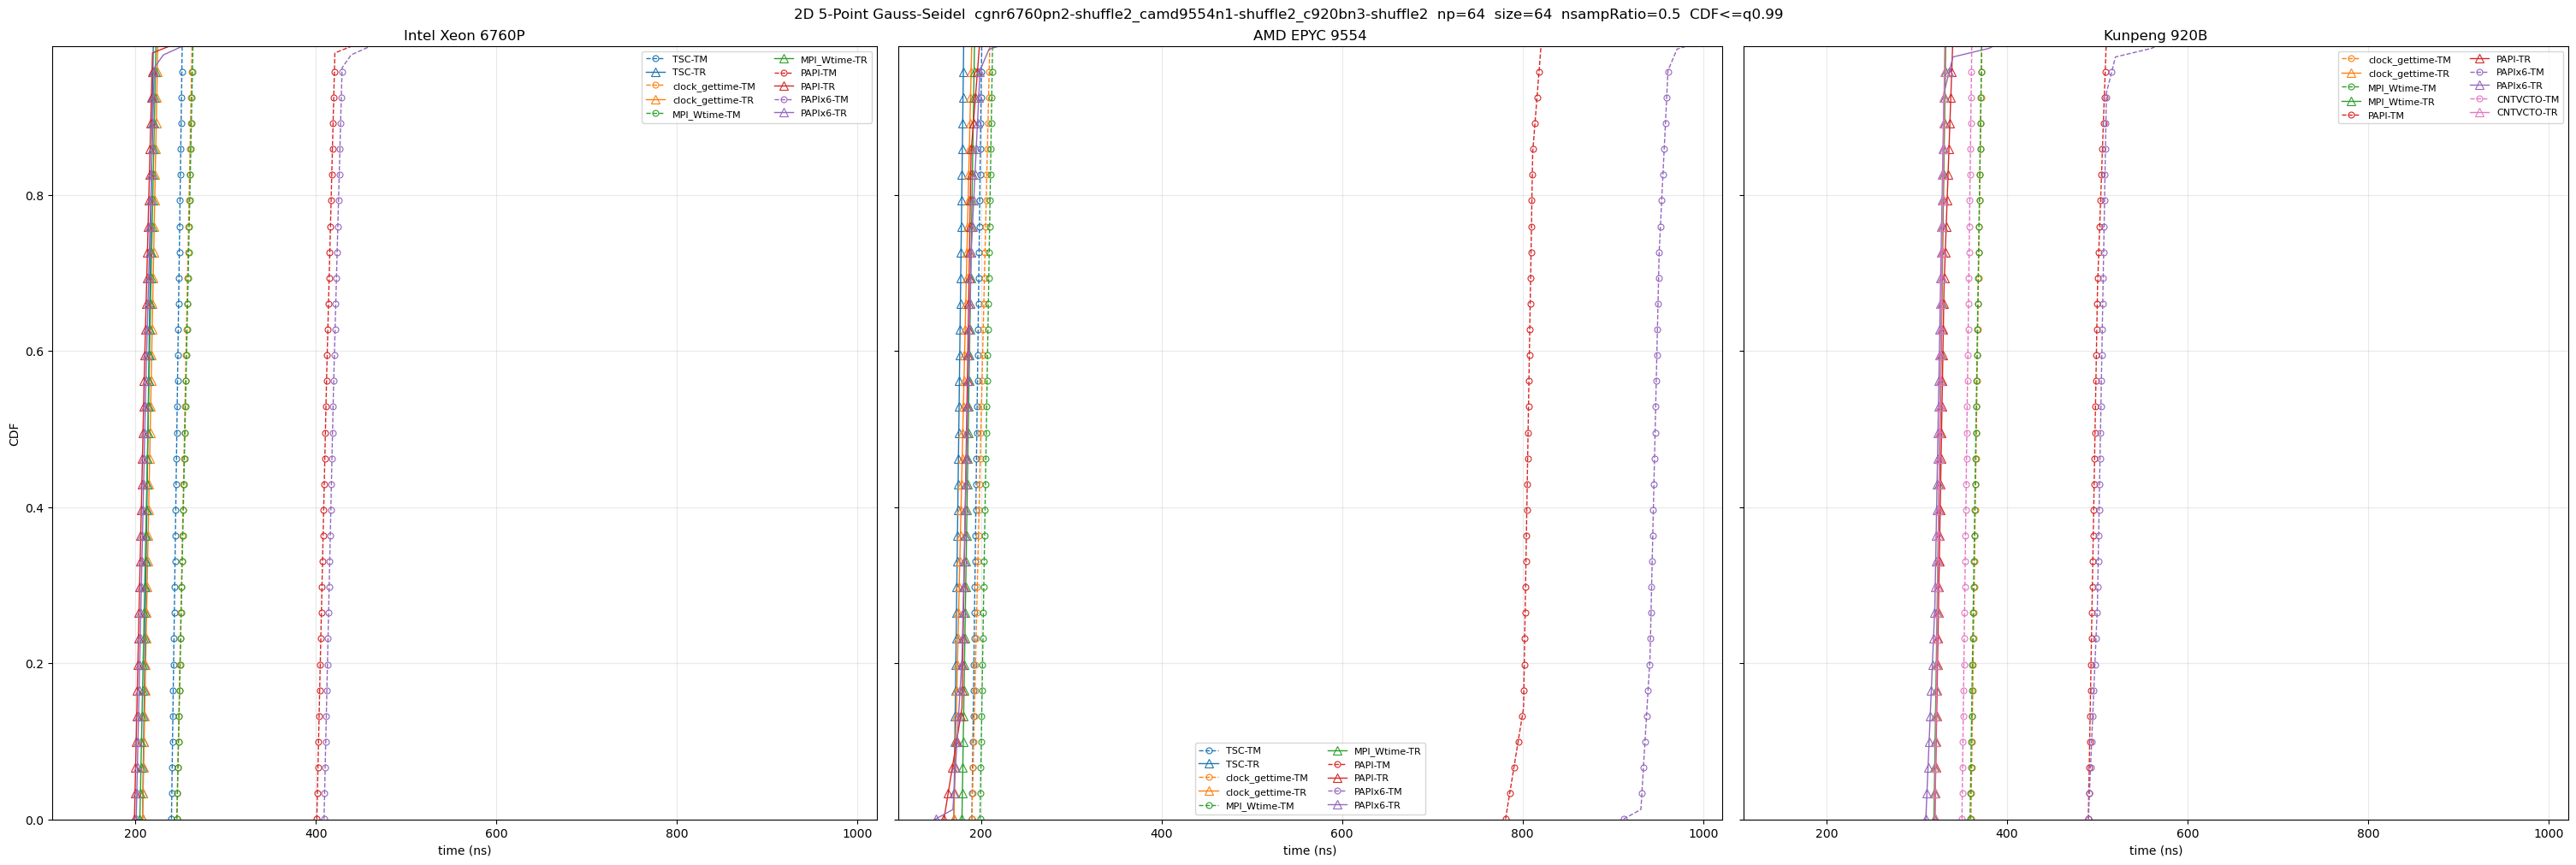

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size128_ratio0.5_tm_tr_by_host.png


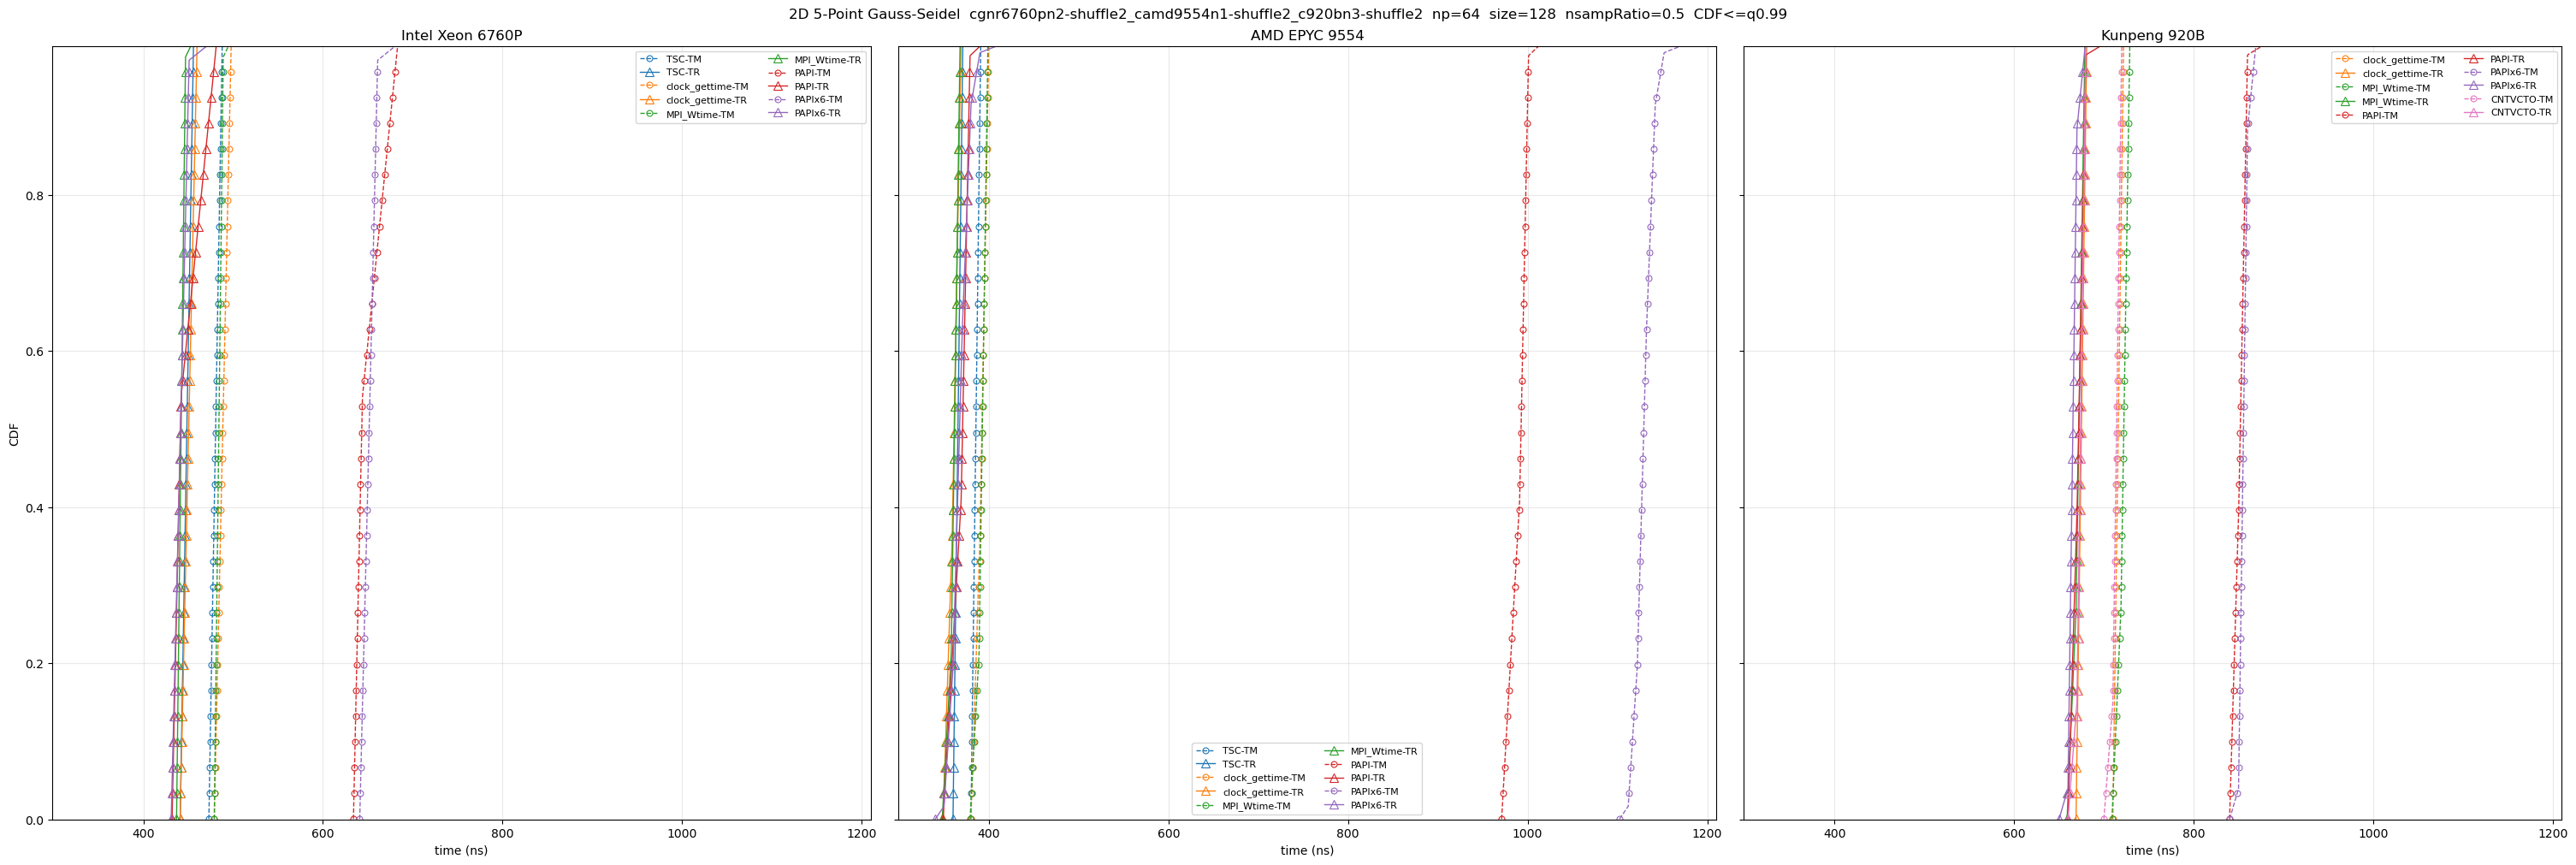

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size256_ratio0.5_tm_tr_by_host.png


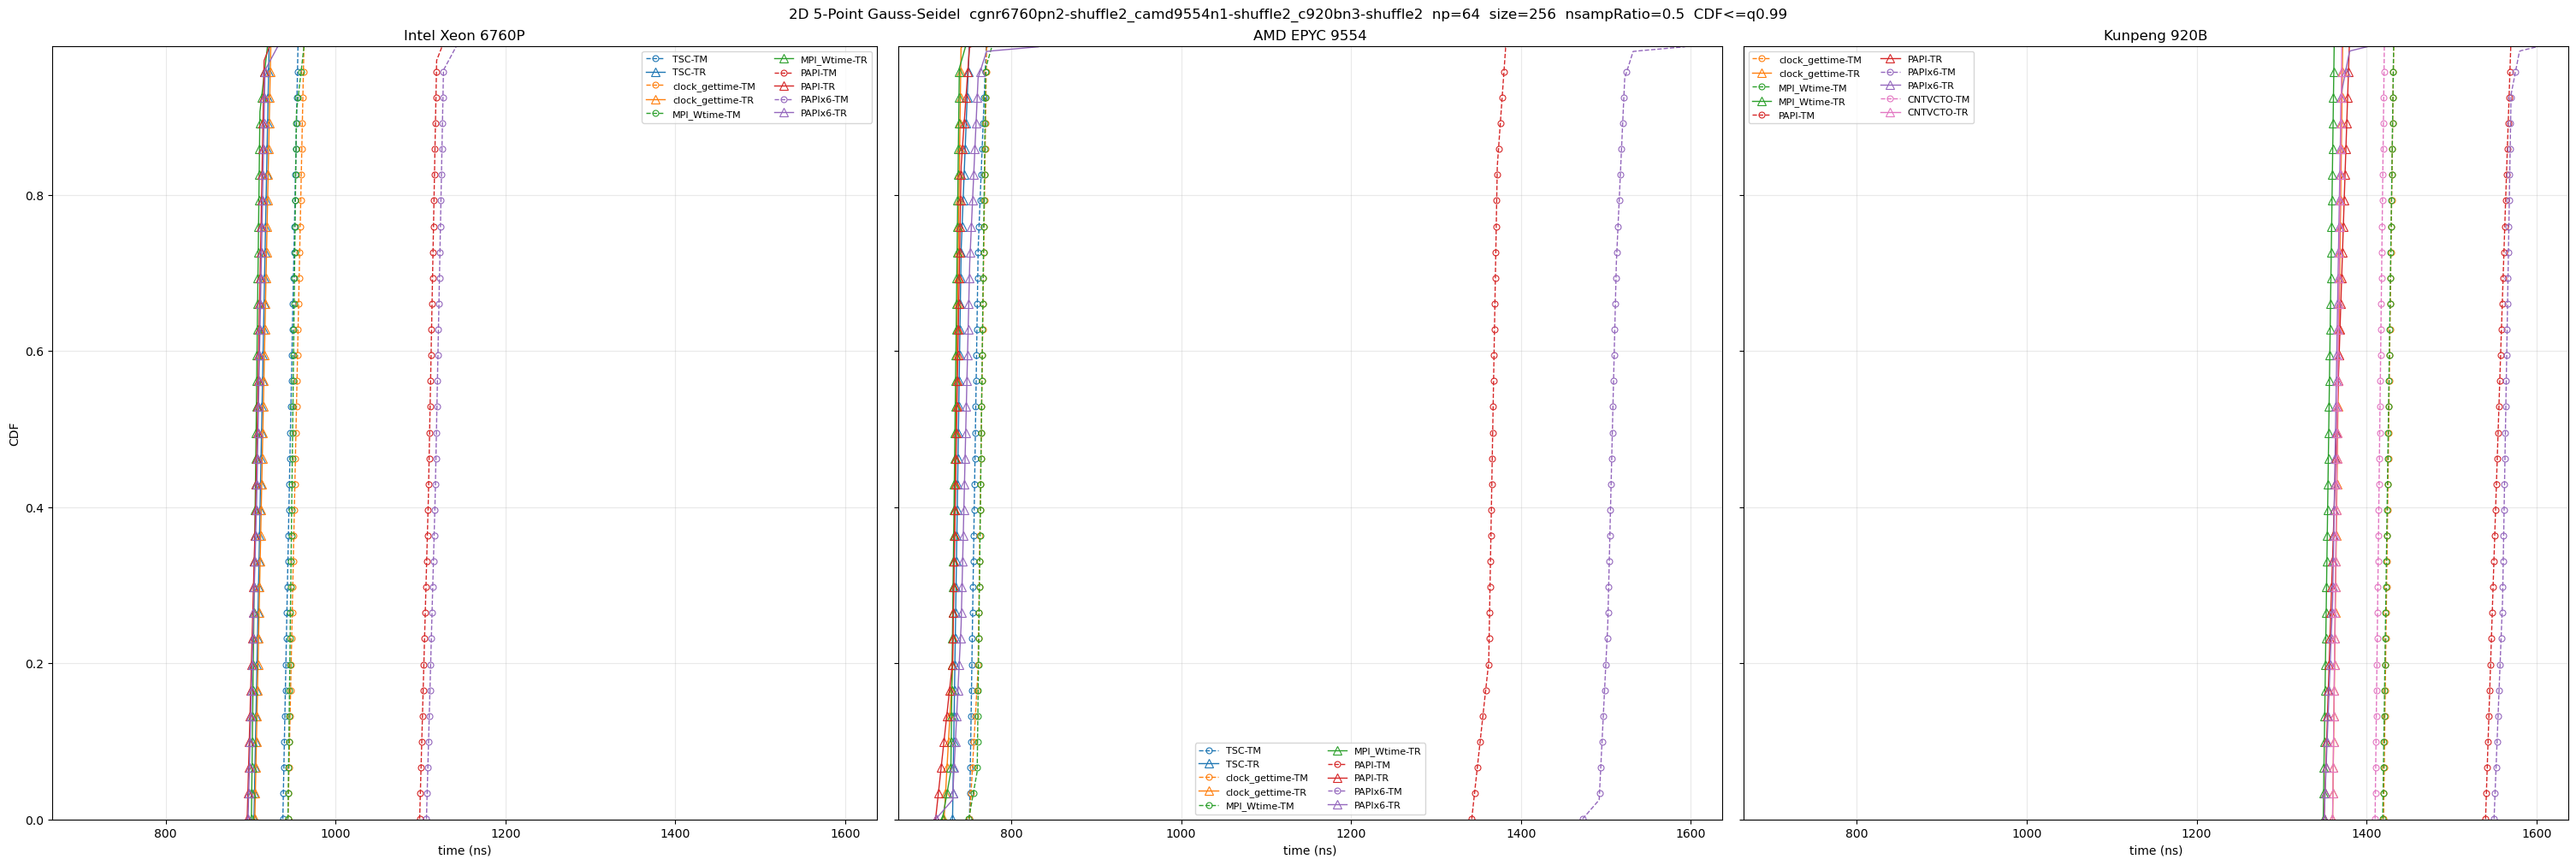

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size512_ratio0.5_tm_tr_by_host.png


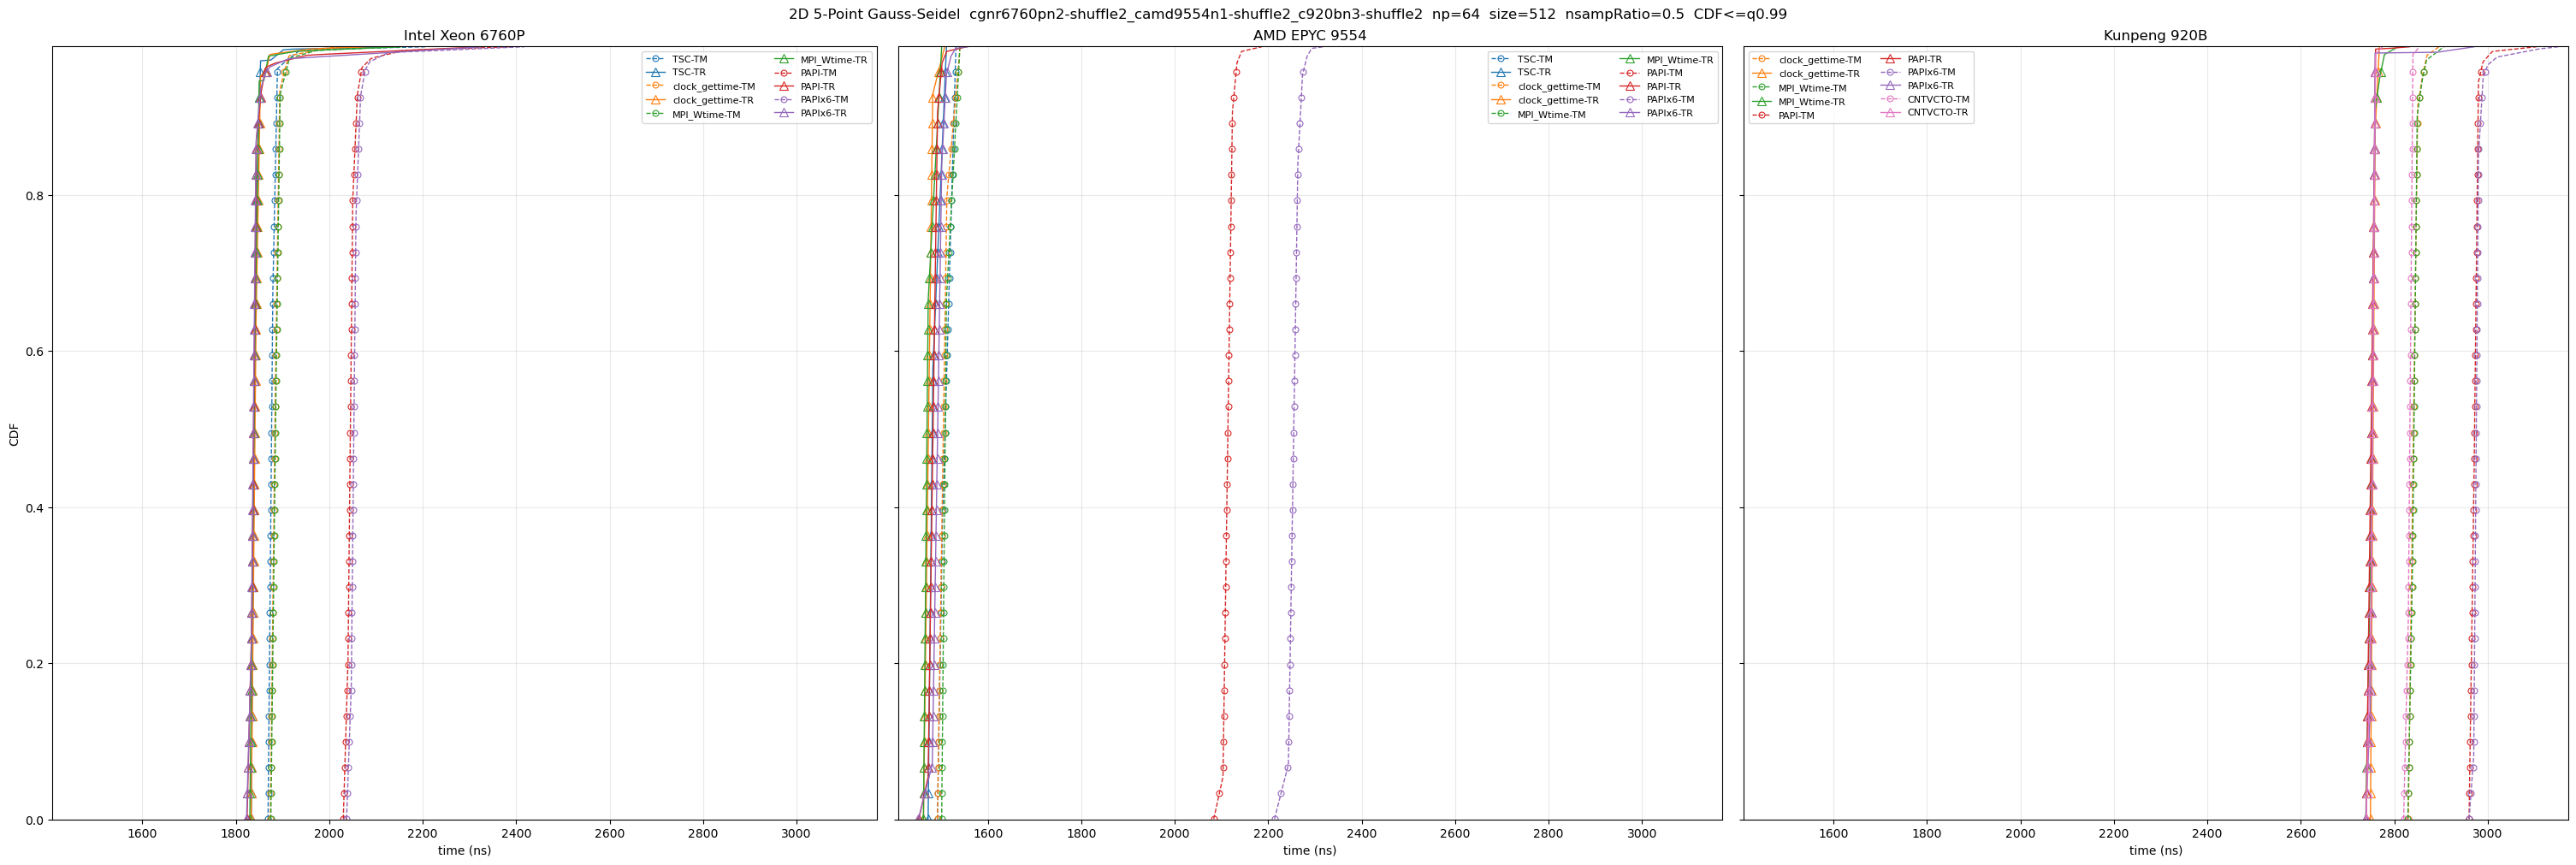

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size1024_ratio0.5_tm_tr_by_host.png


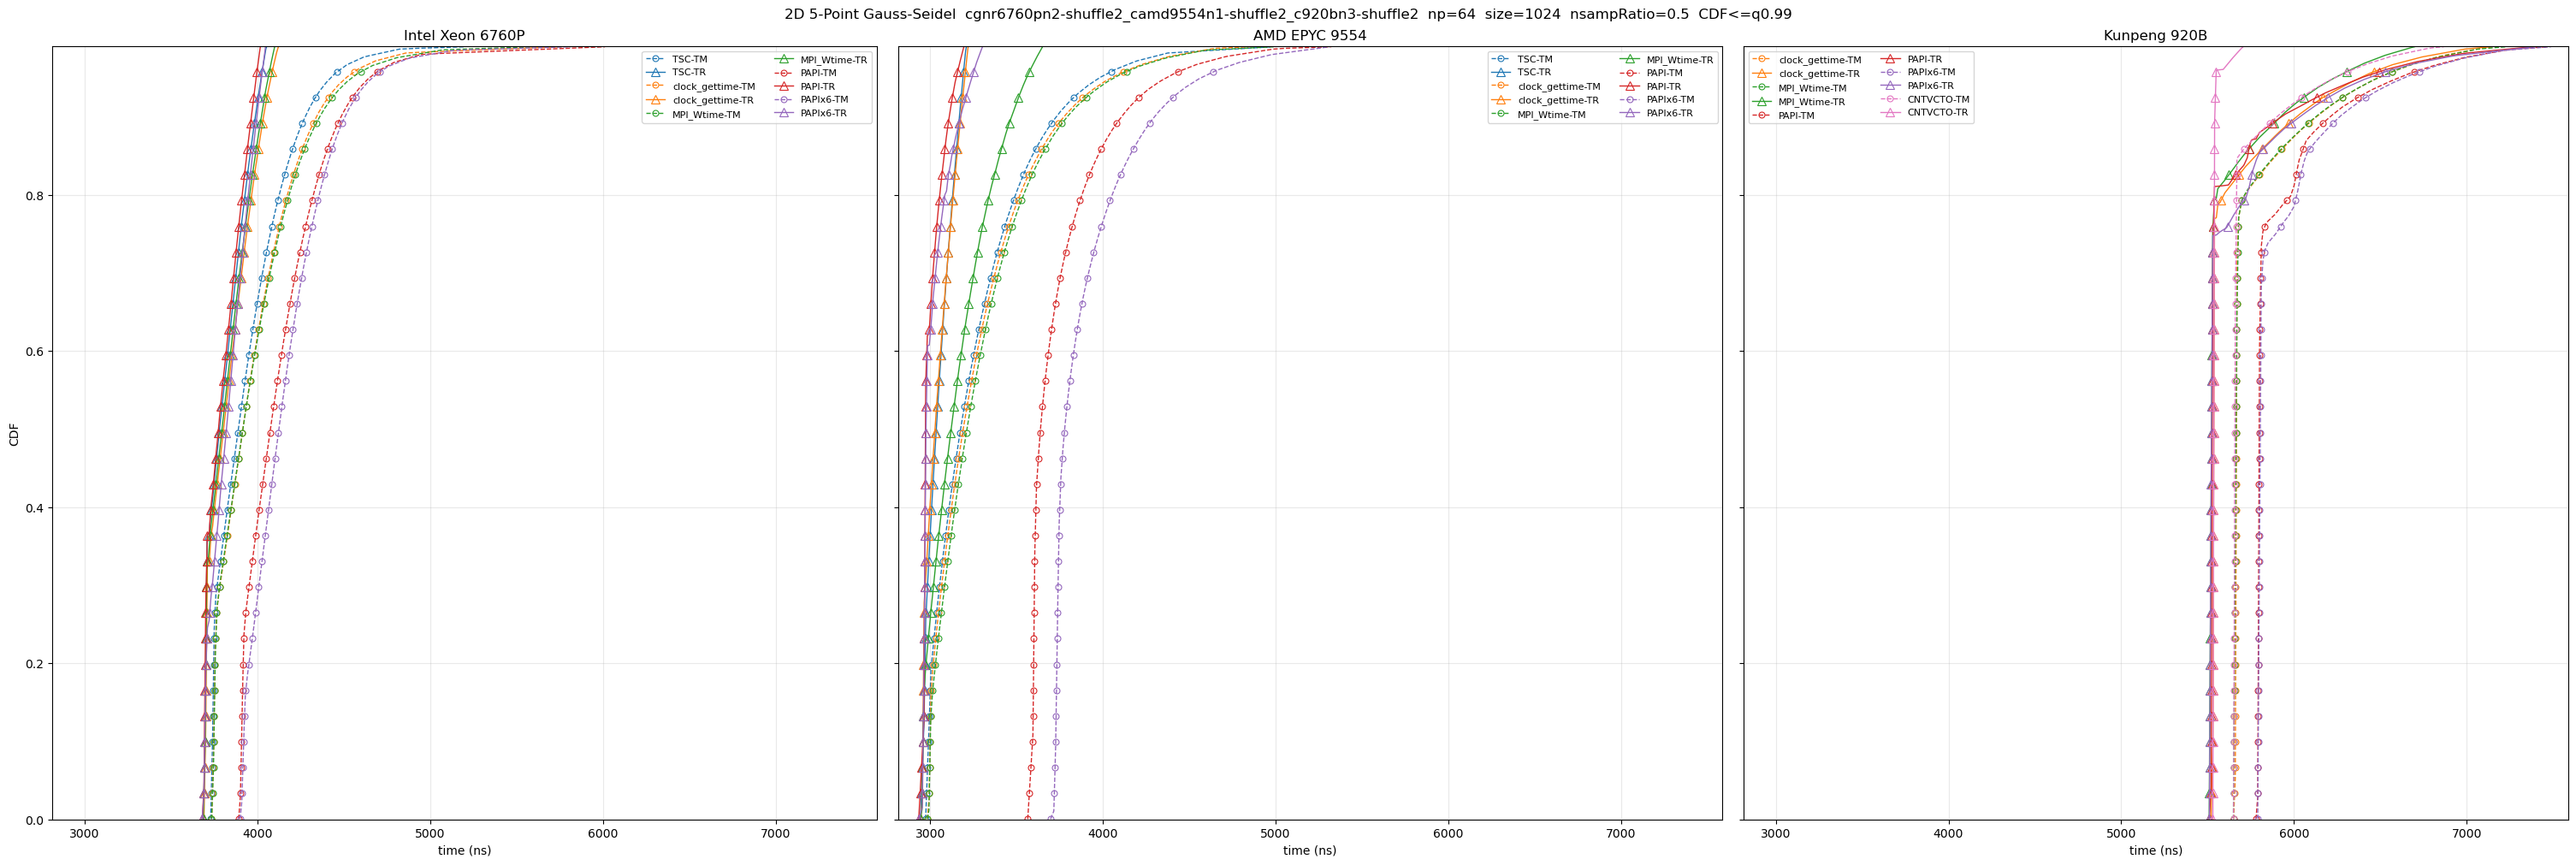

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size2048_ratio0.5_tm_tr_by_host.png


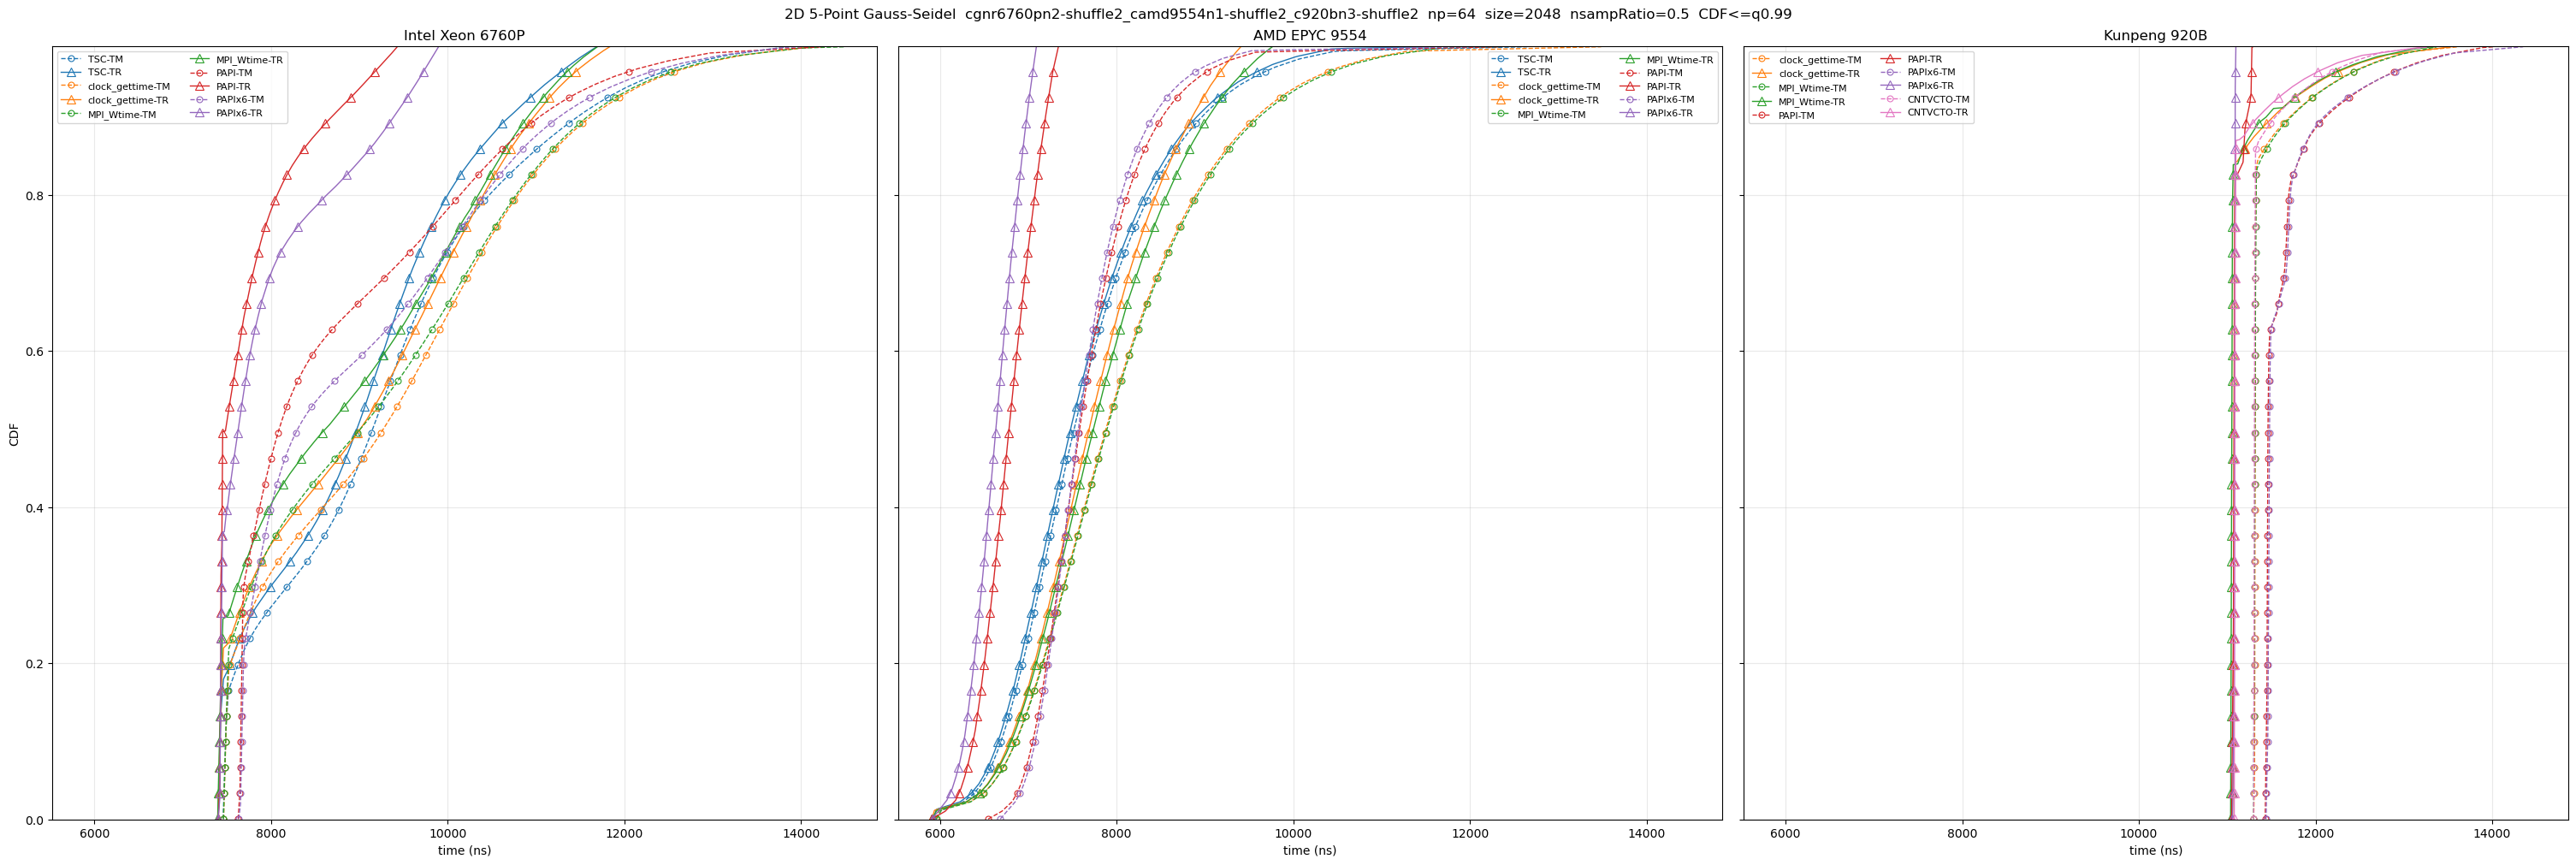

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/jacobi2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size64_ratio0.5_tm_tr_by_host.png


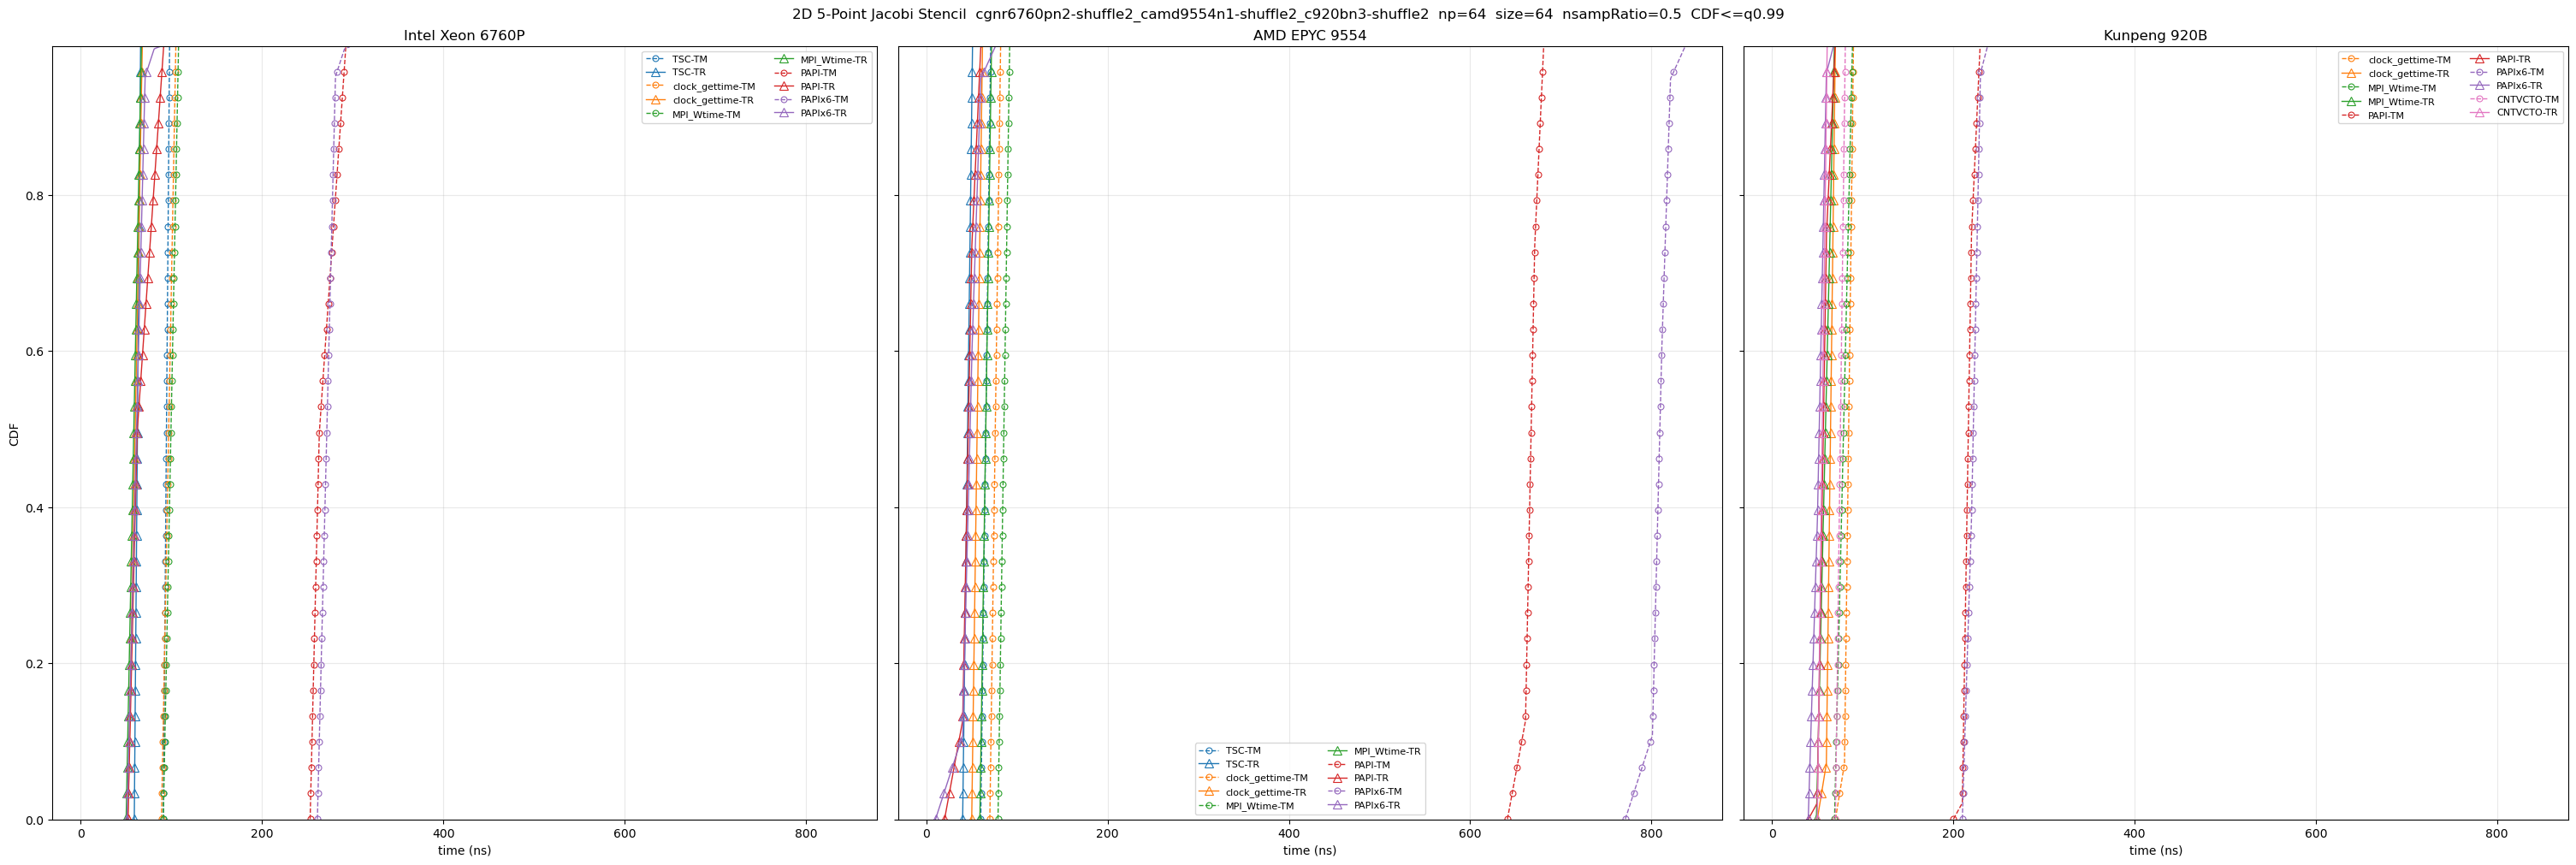

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/jacobi2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size128_ratio0.5_tm_tr_by_host.png


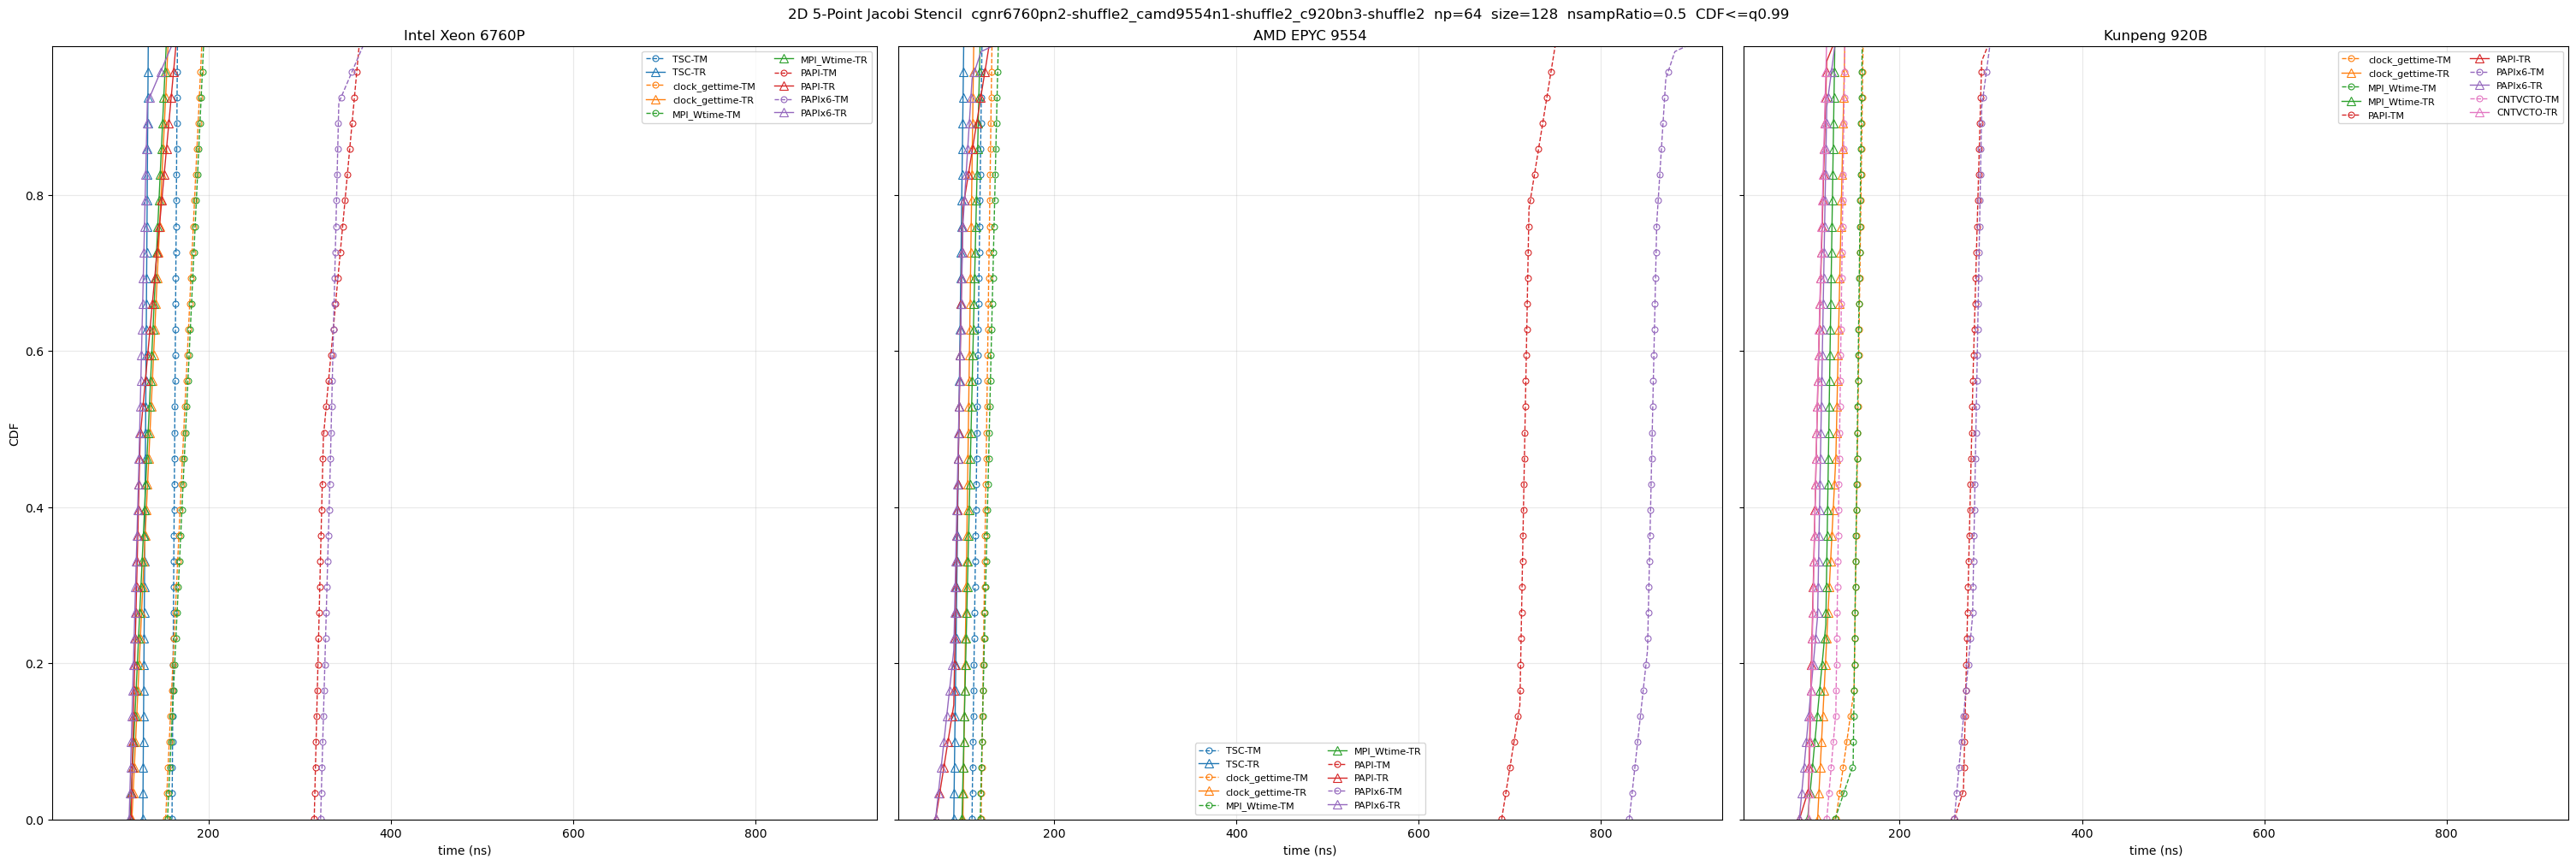

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/jacobi2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size256_ratio0.5_tm_tr_by_host.png


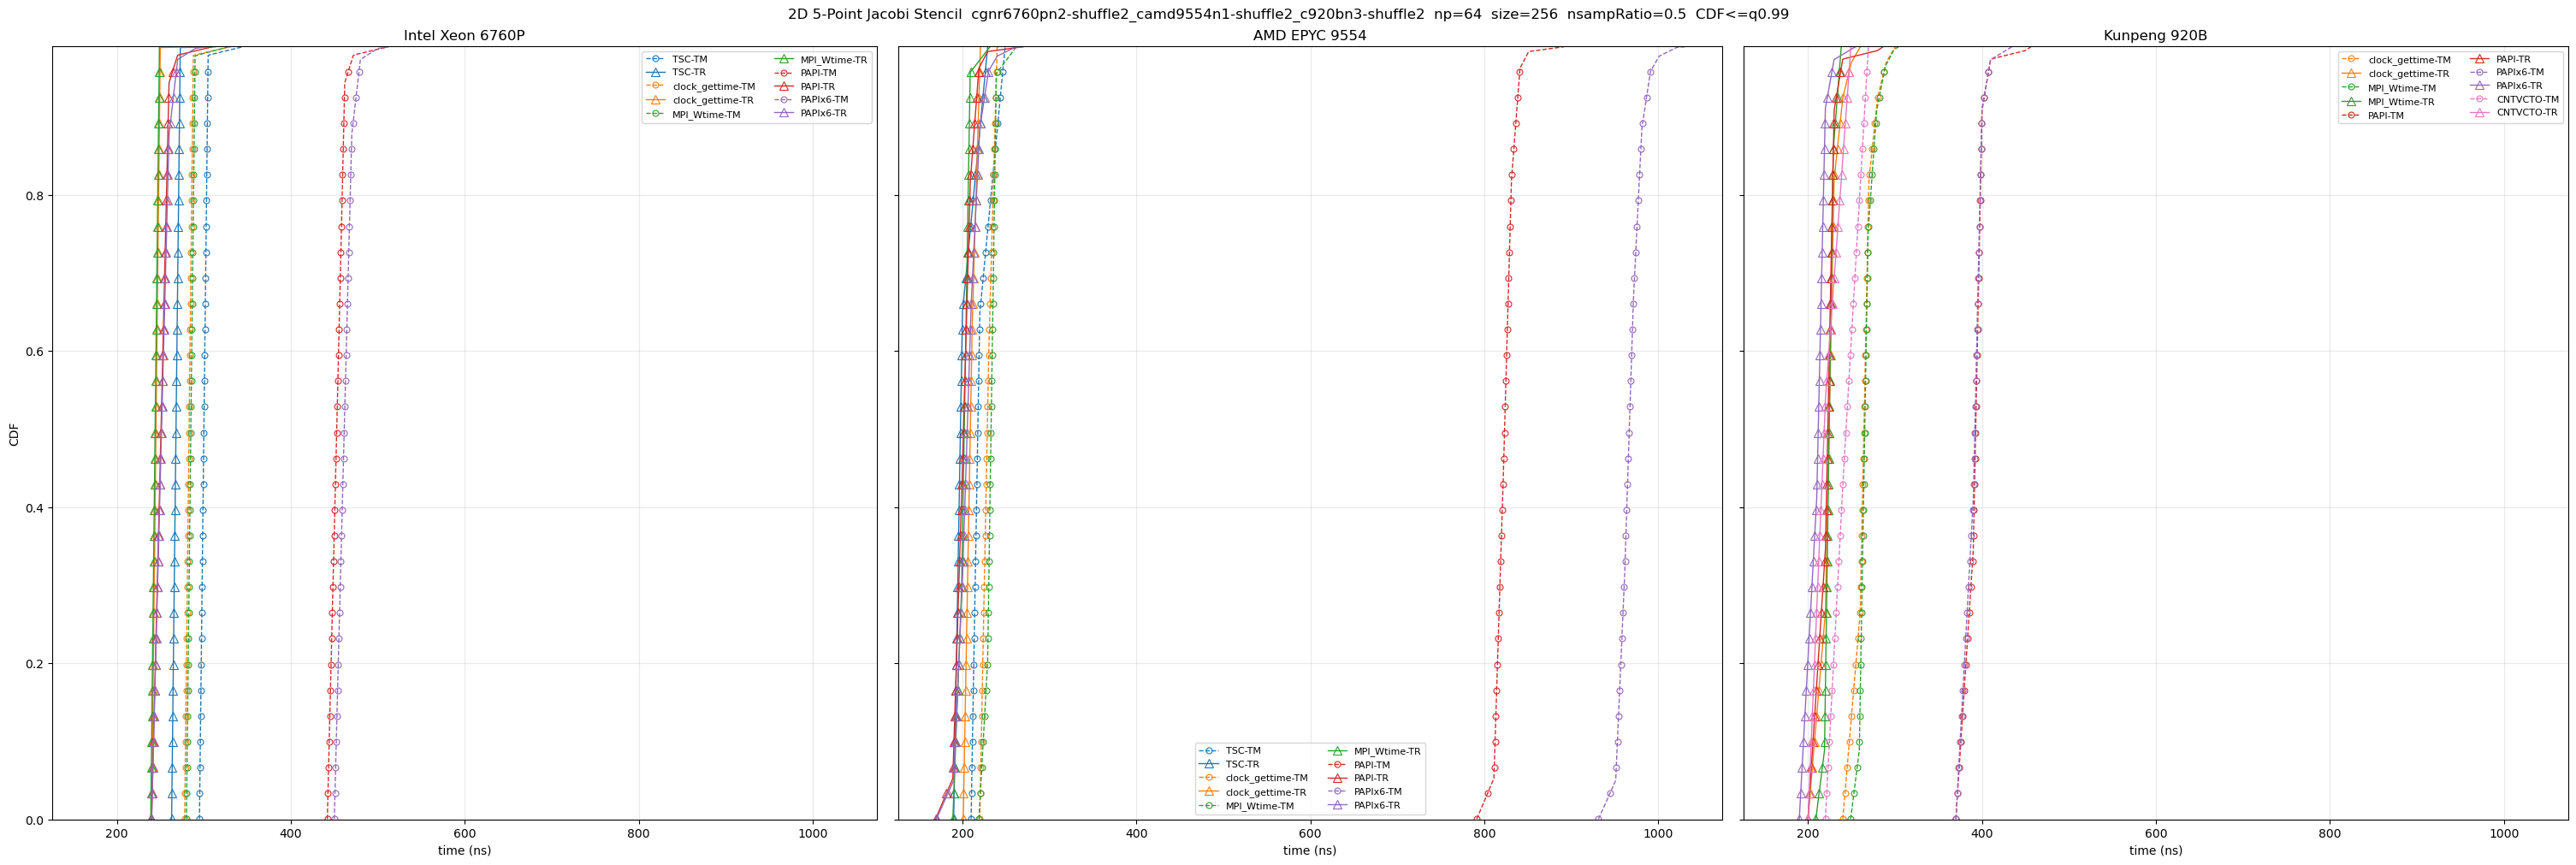

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/jacobi2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size512_ratio0.5_tm_tr_by_host.png


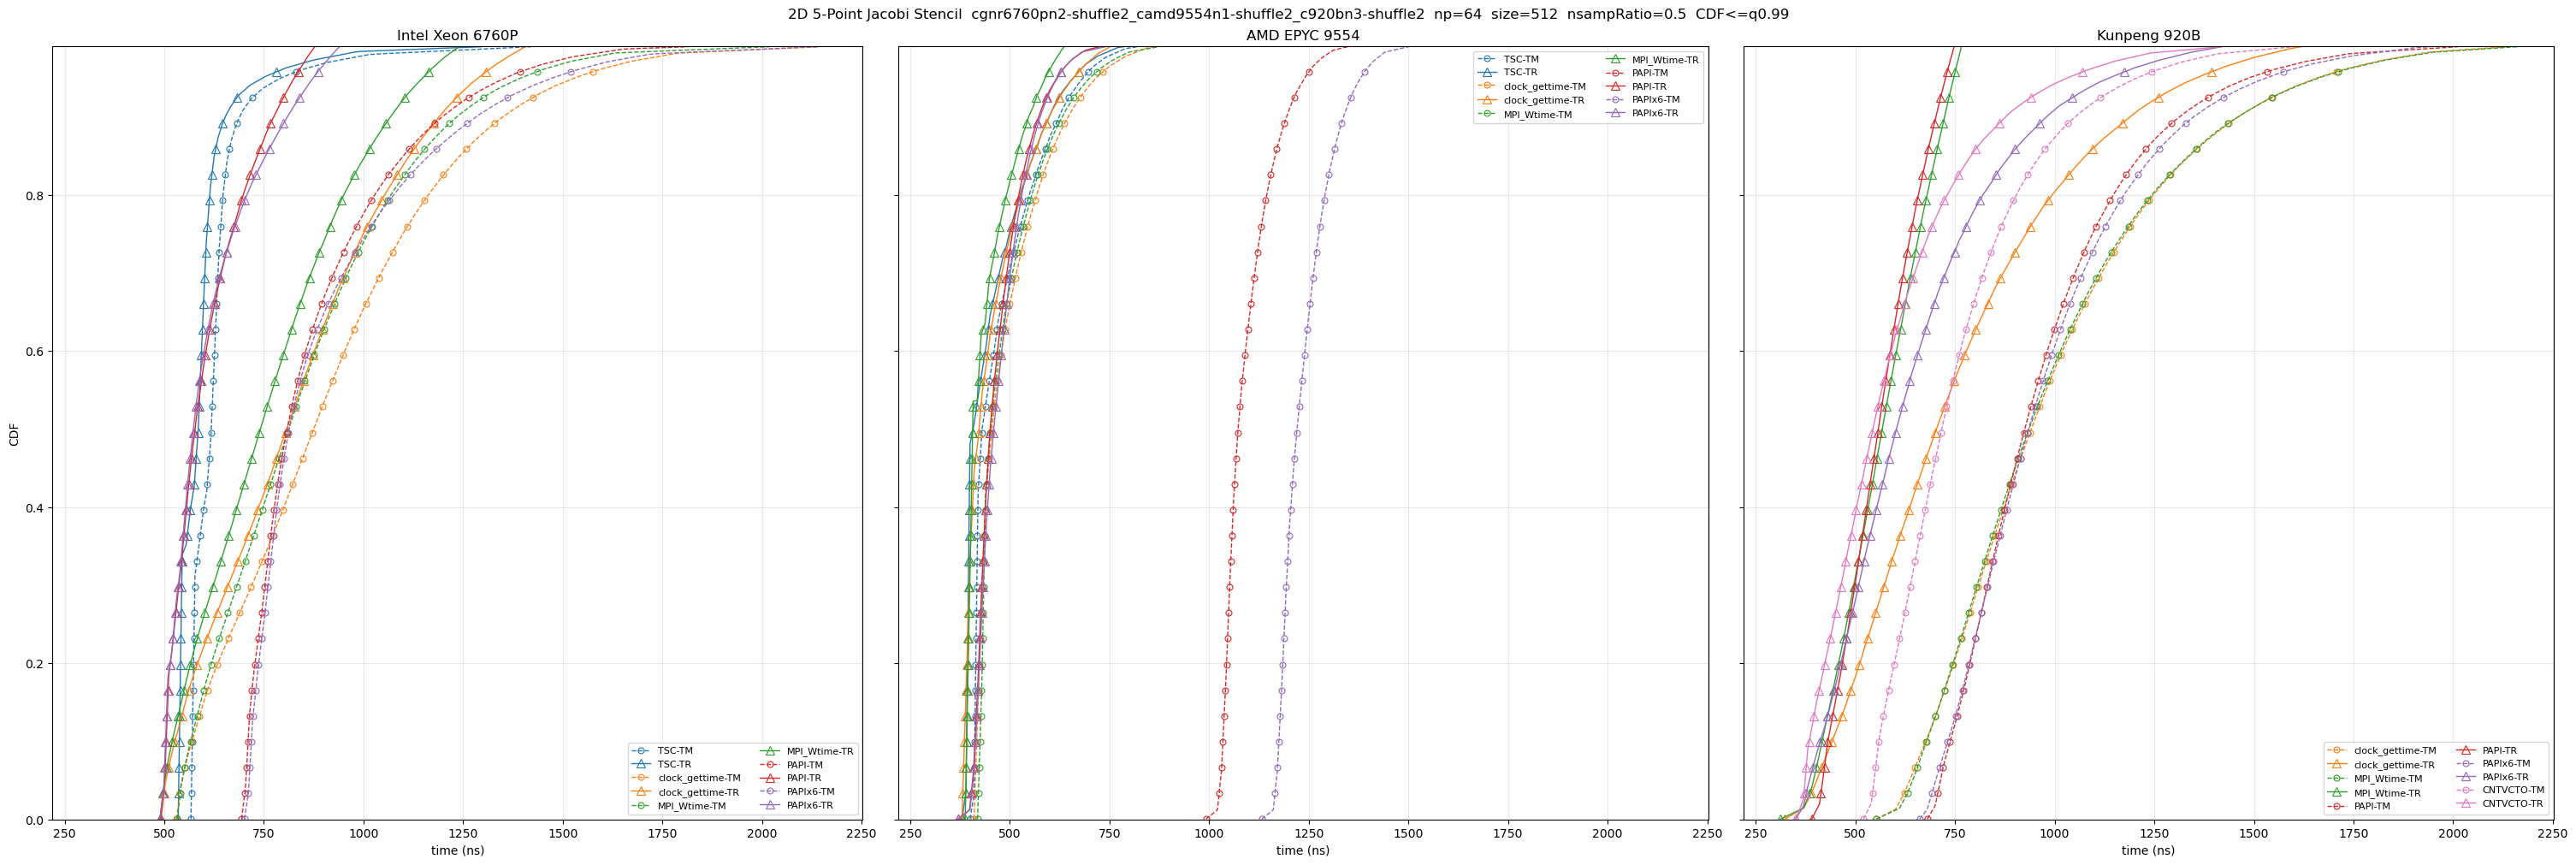

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/jacobi2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size1024_ratio0.5_tm_tr_by_host.png


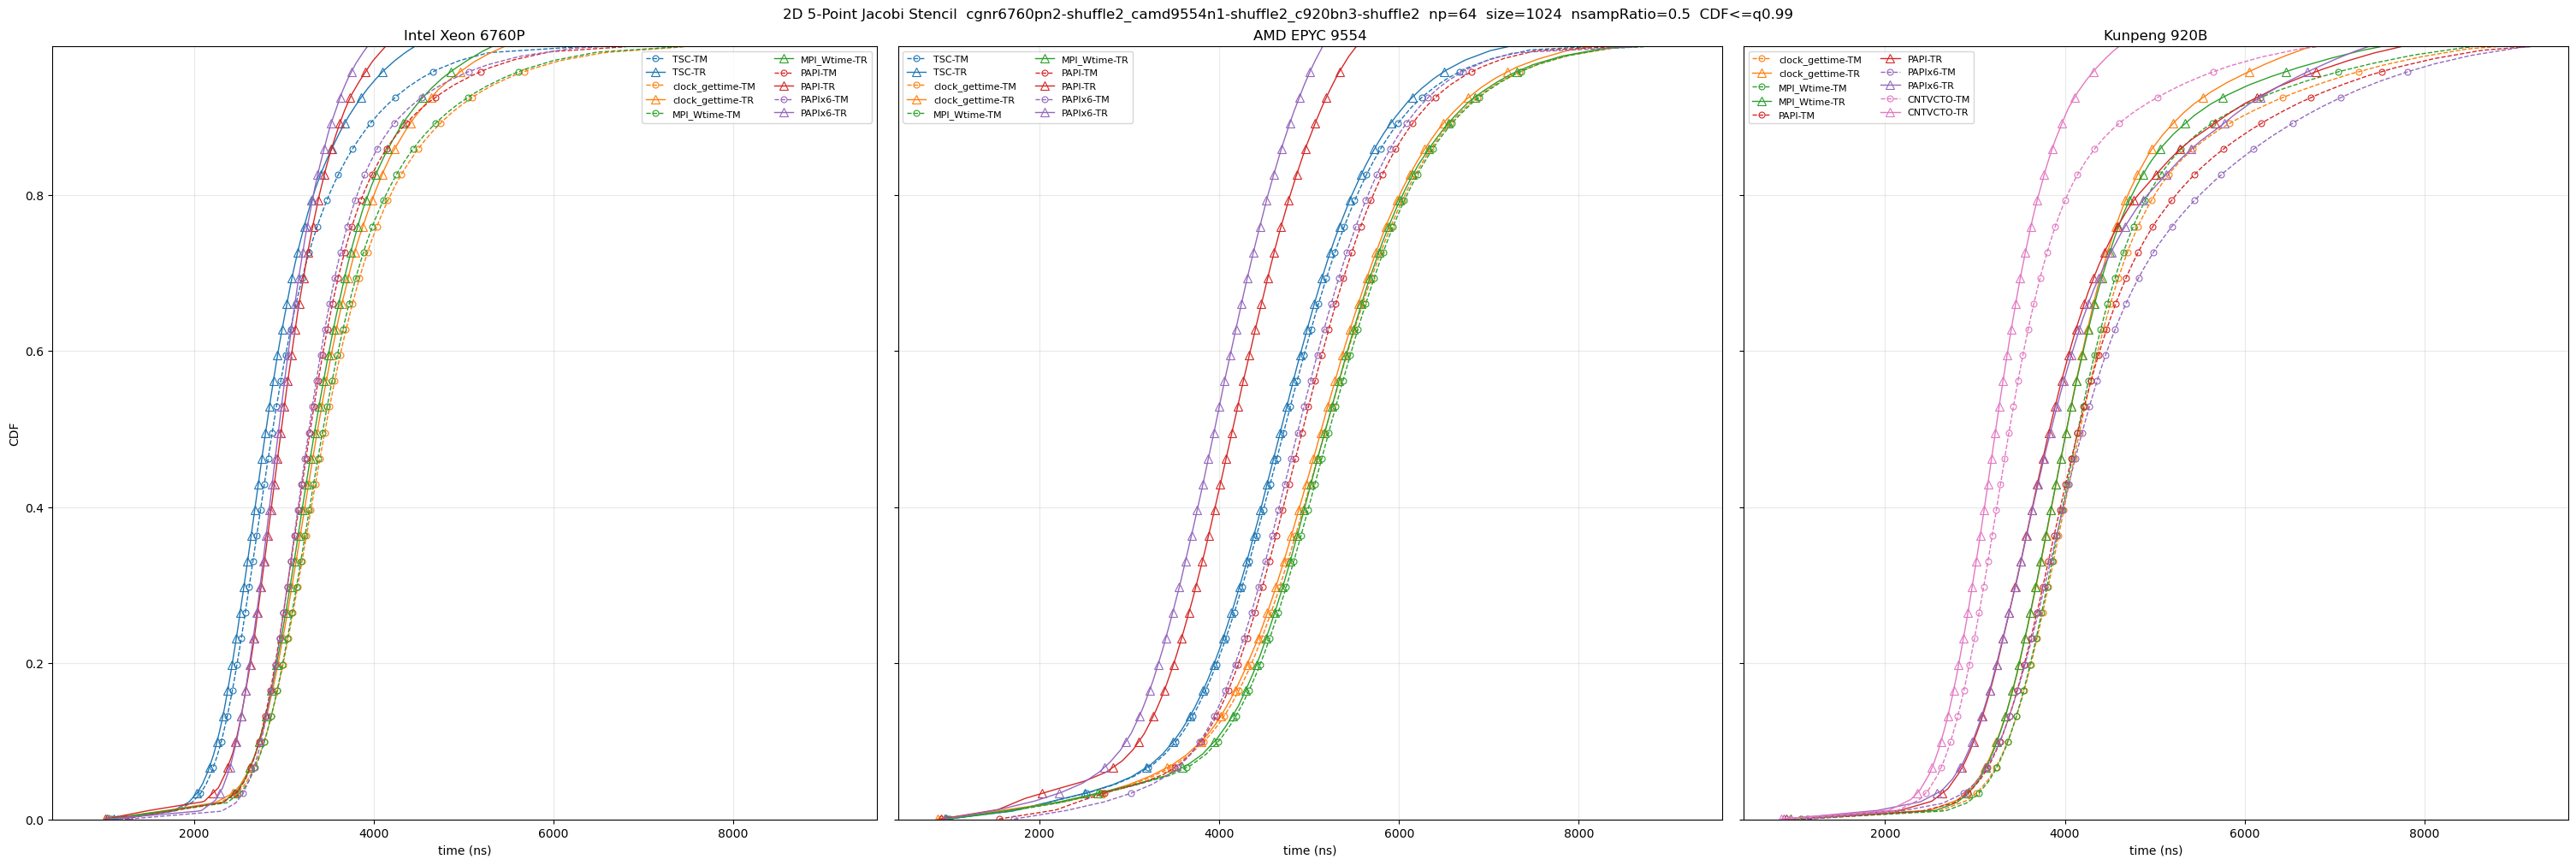

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/jacobi2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size2048_ratio0.5_tm_tr_by_host.png


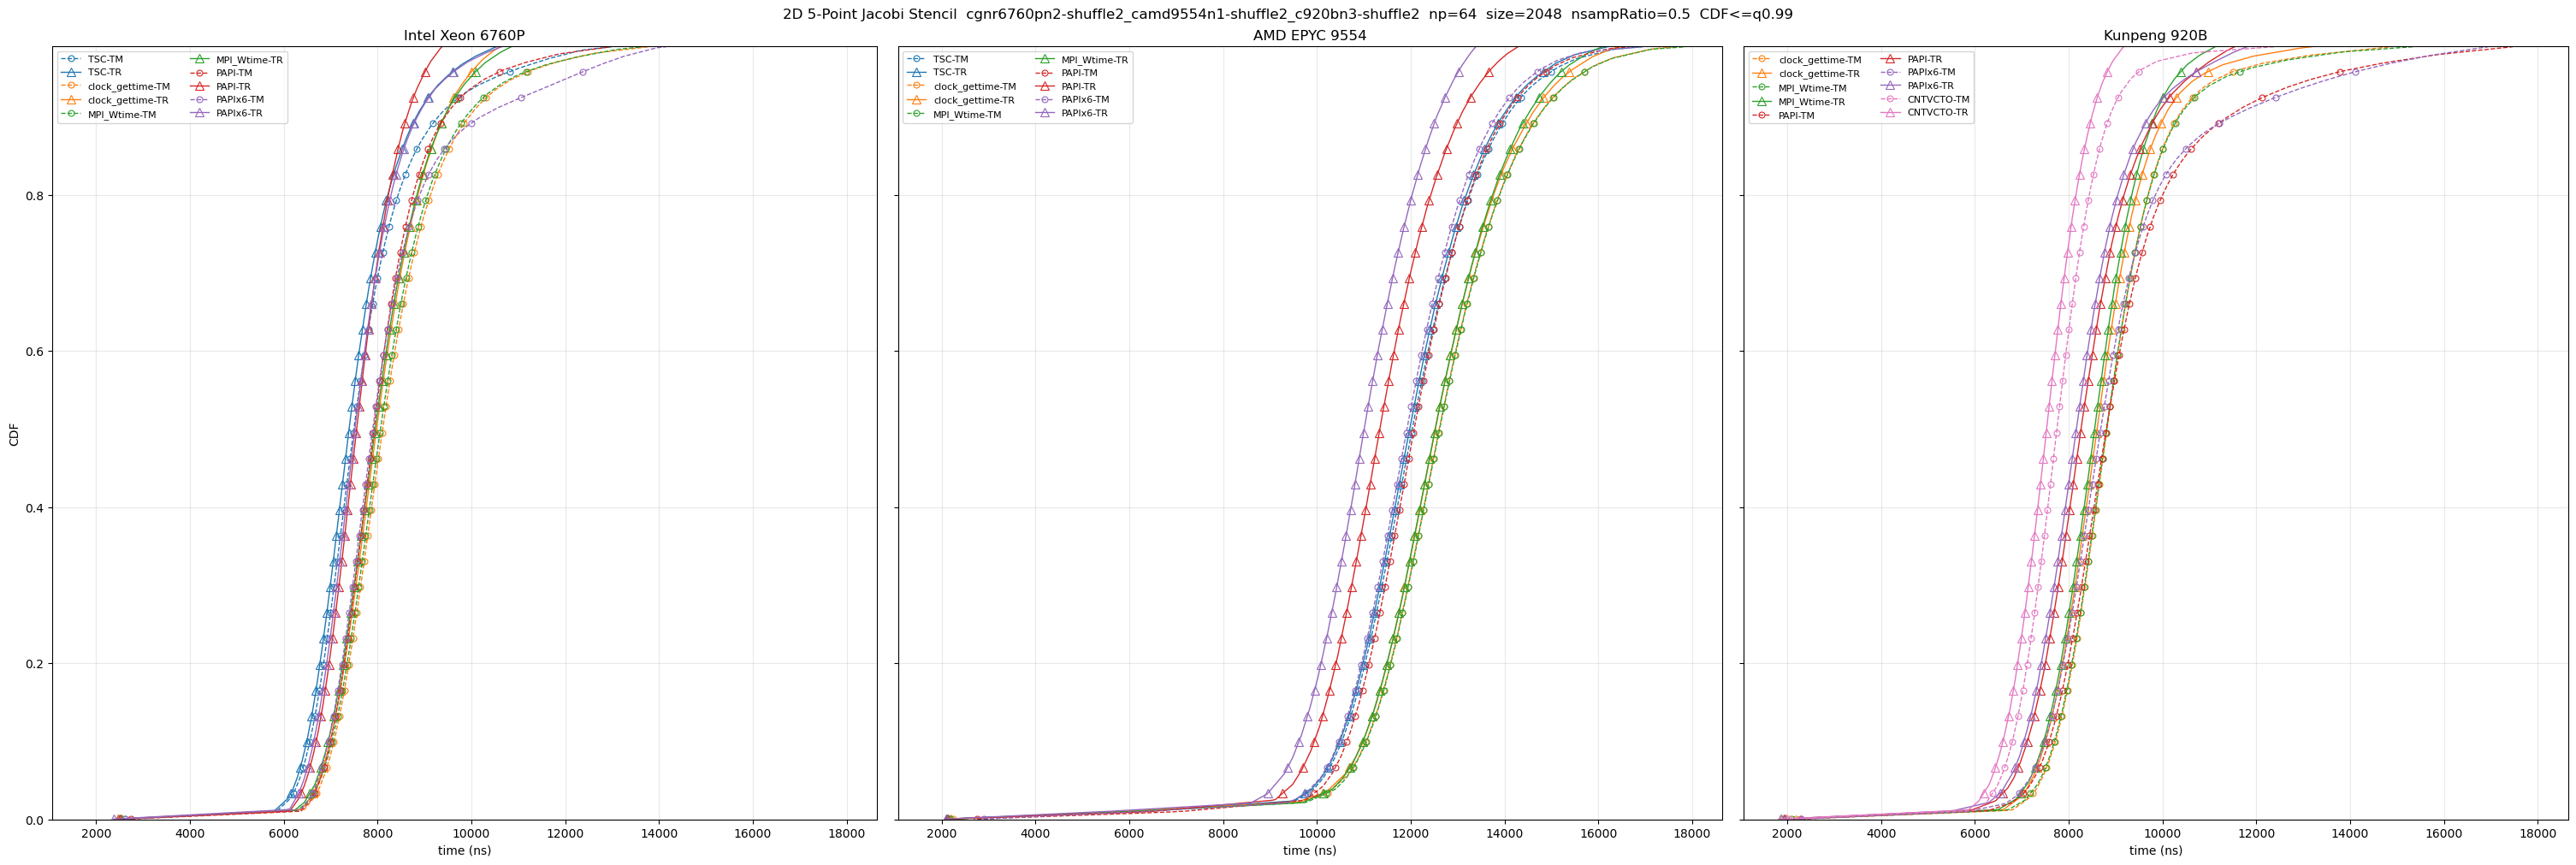

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size64_ratio0.5_tm_tr_by_host.png


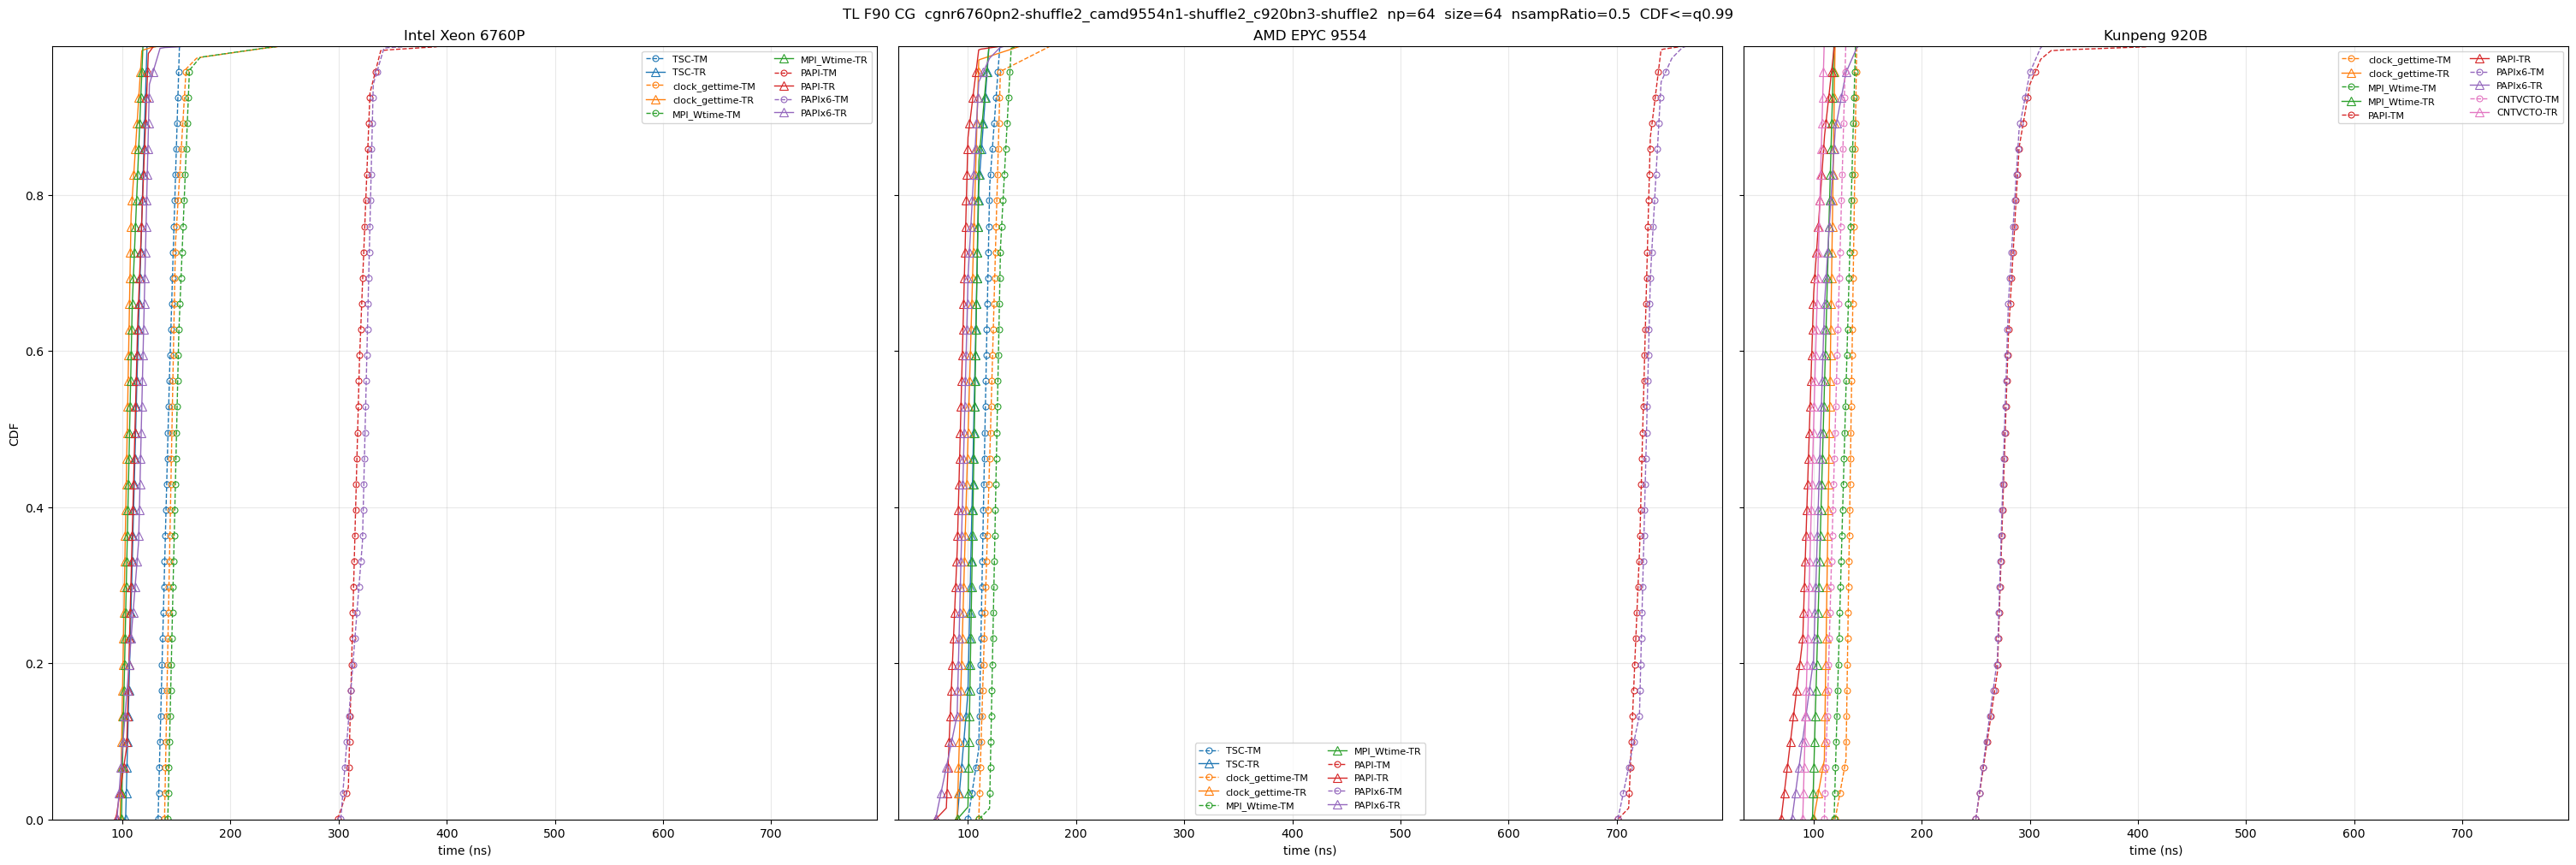

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size128_ratio0.5_tm_tr_by_host.png


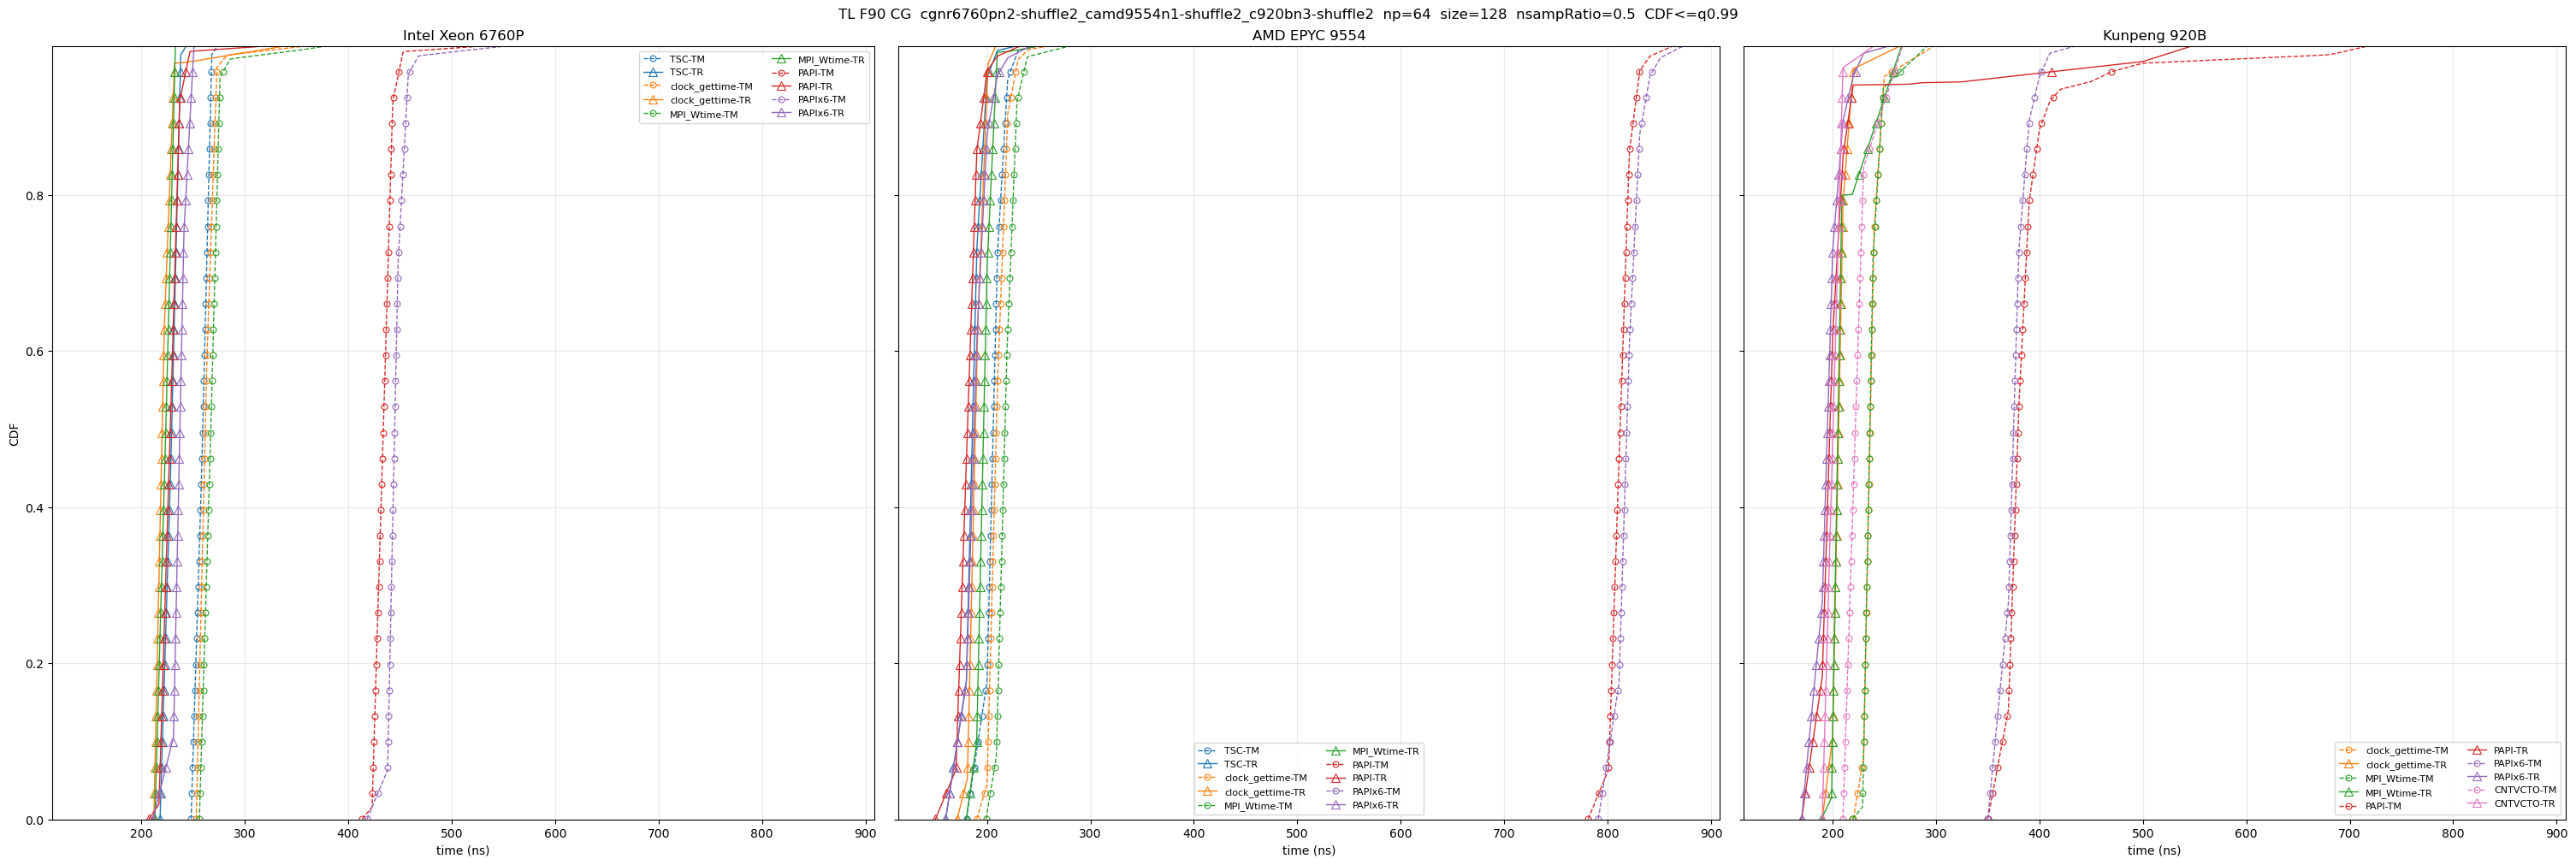

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size256_ratio0.5_tm_tr_by_host.png


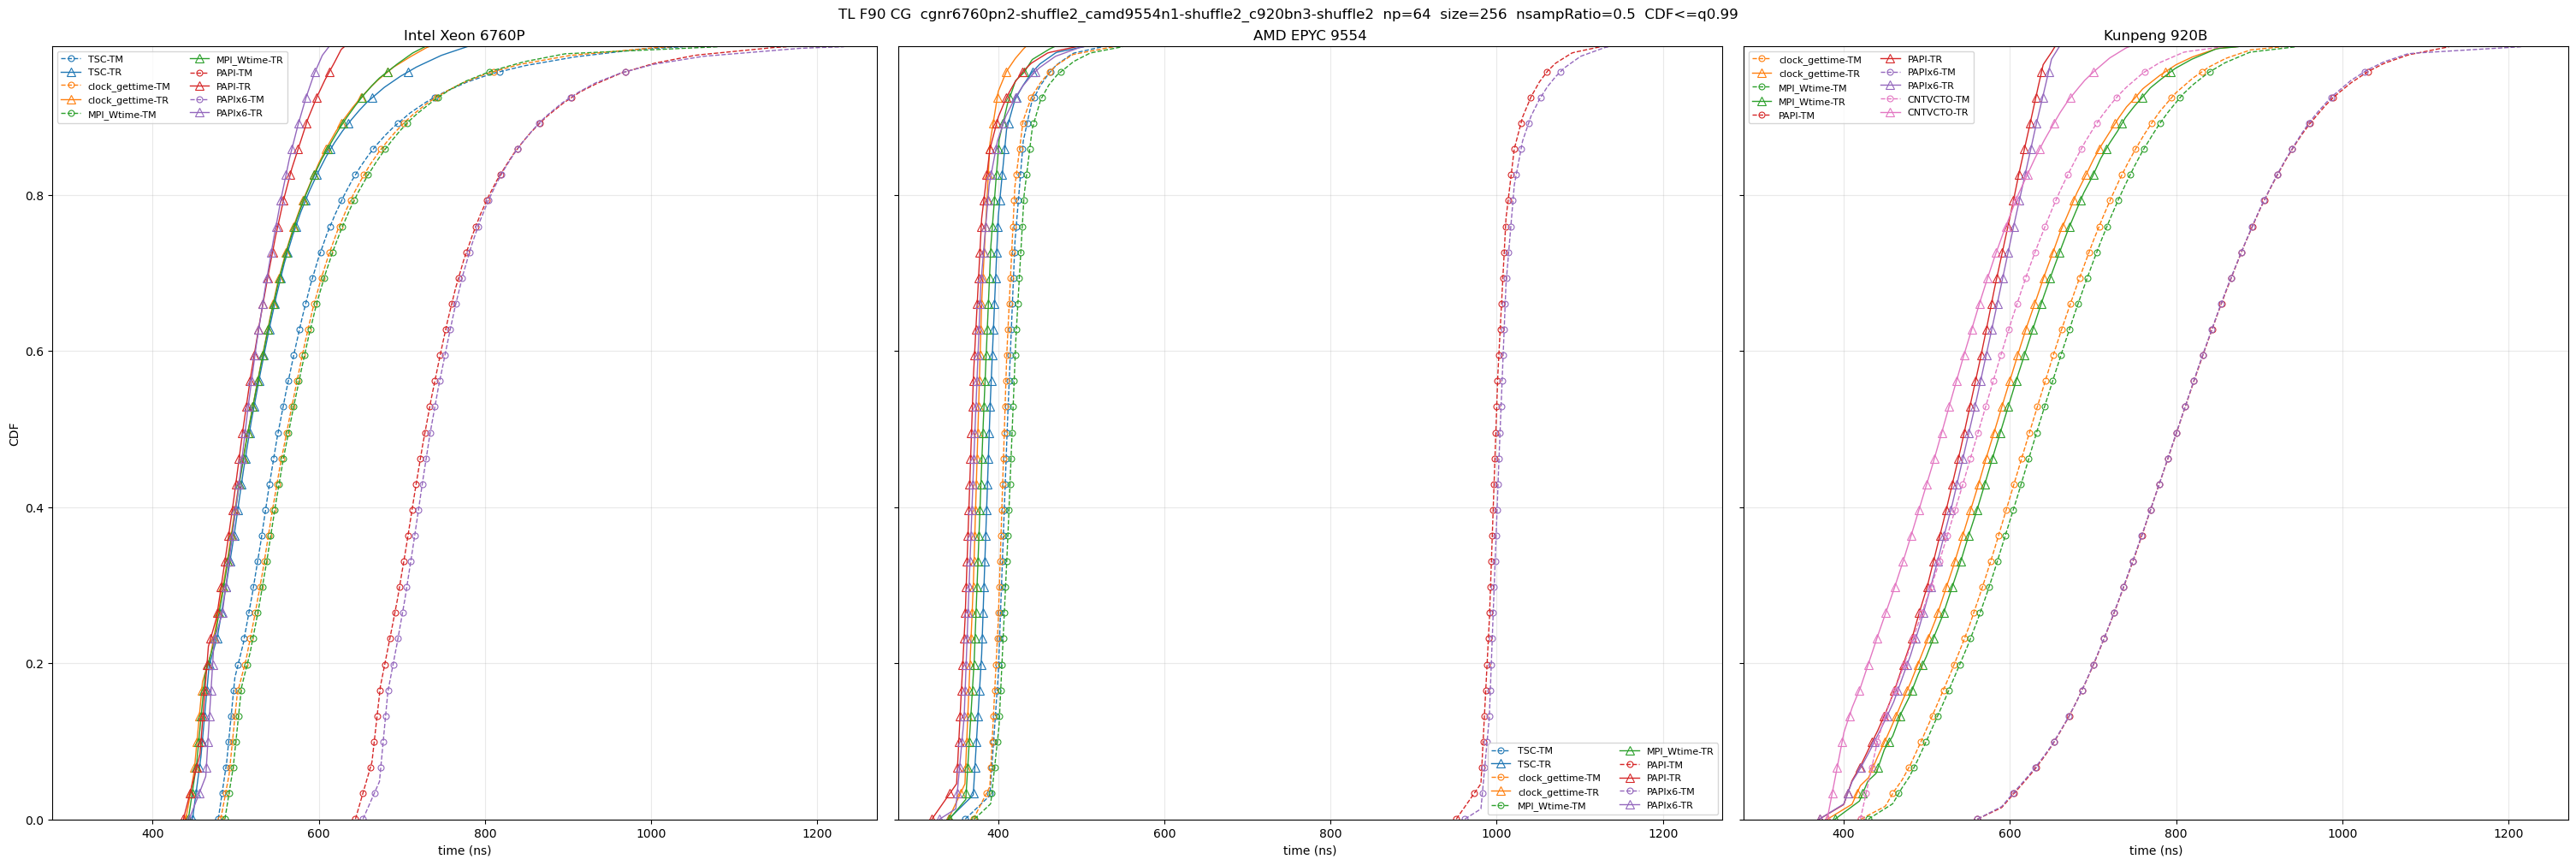

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size512_ratio0.5_tm_tr_by_host.png


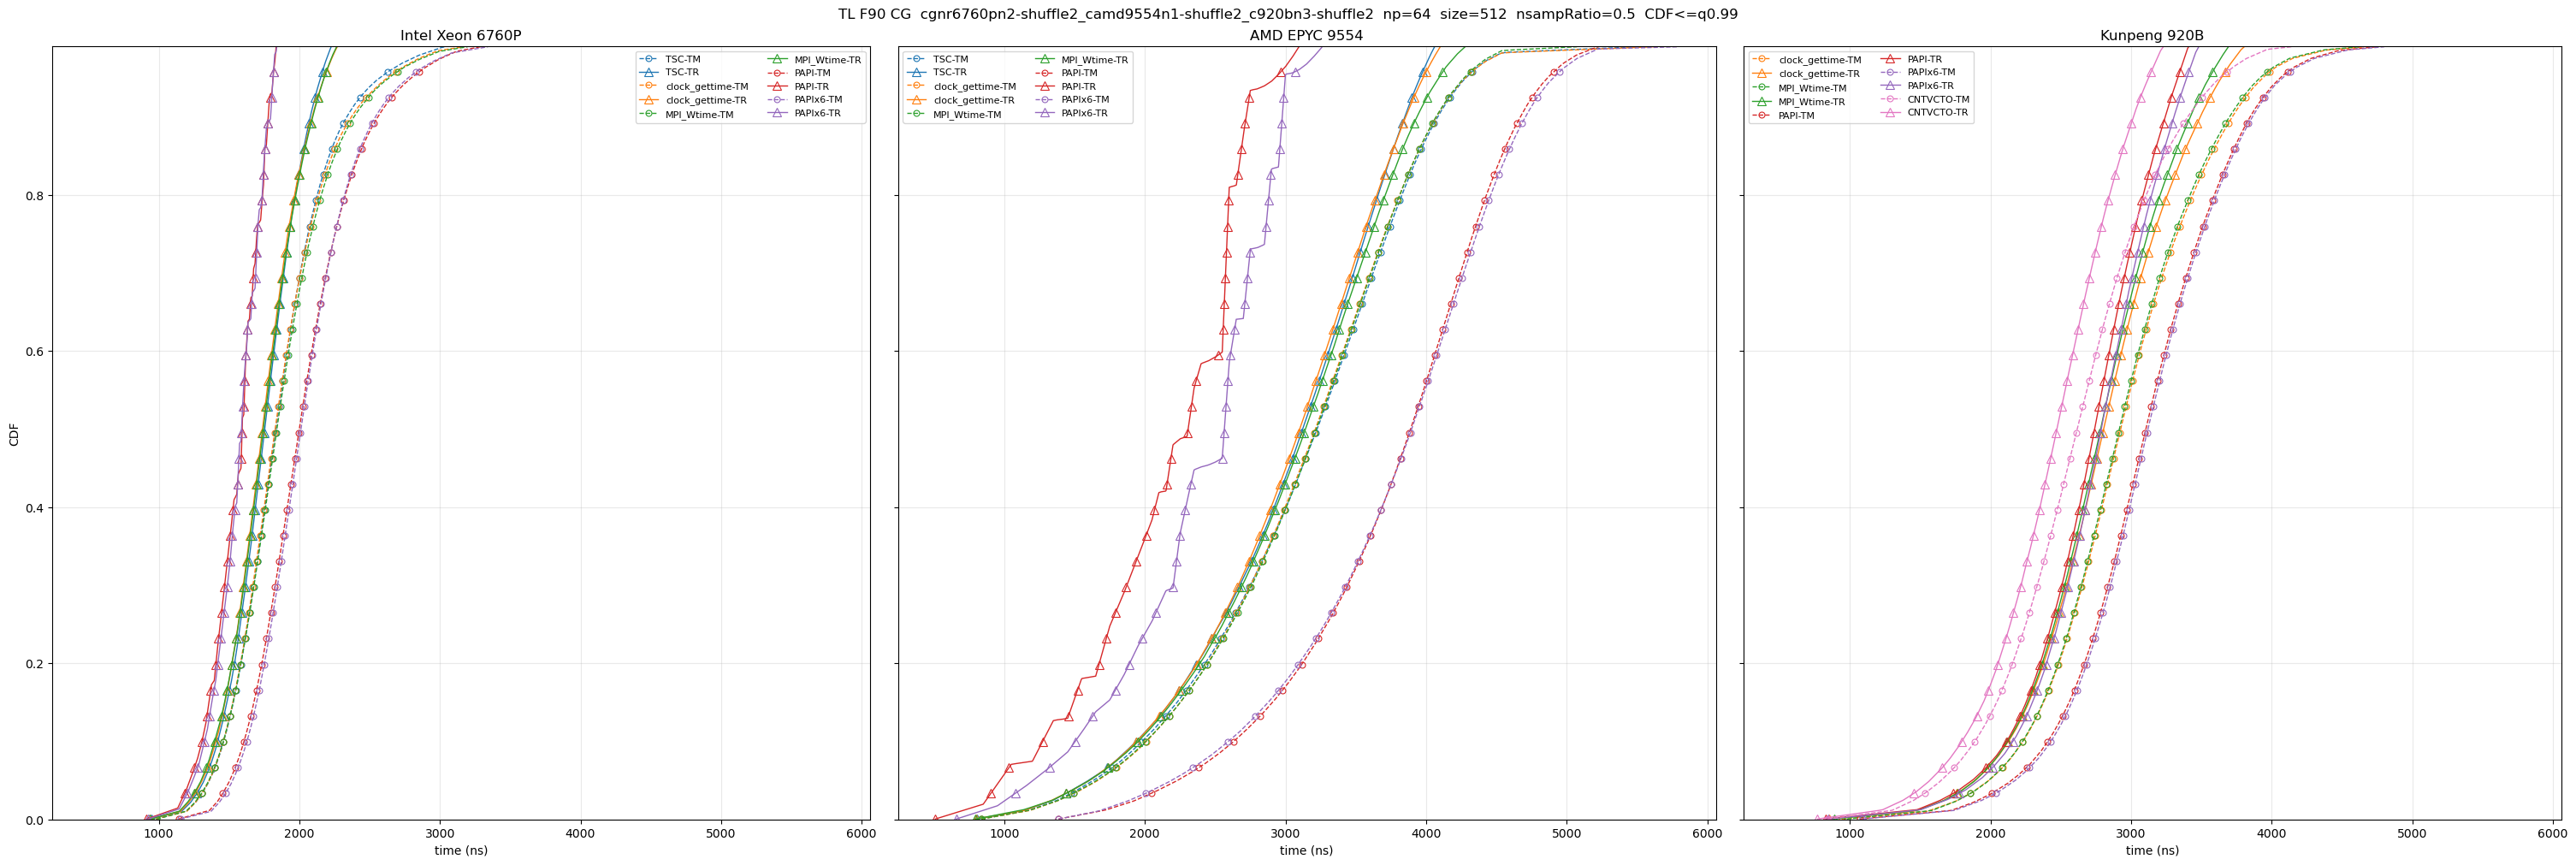

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size1024_ratio0.5_tm_tr_by_host.png


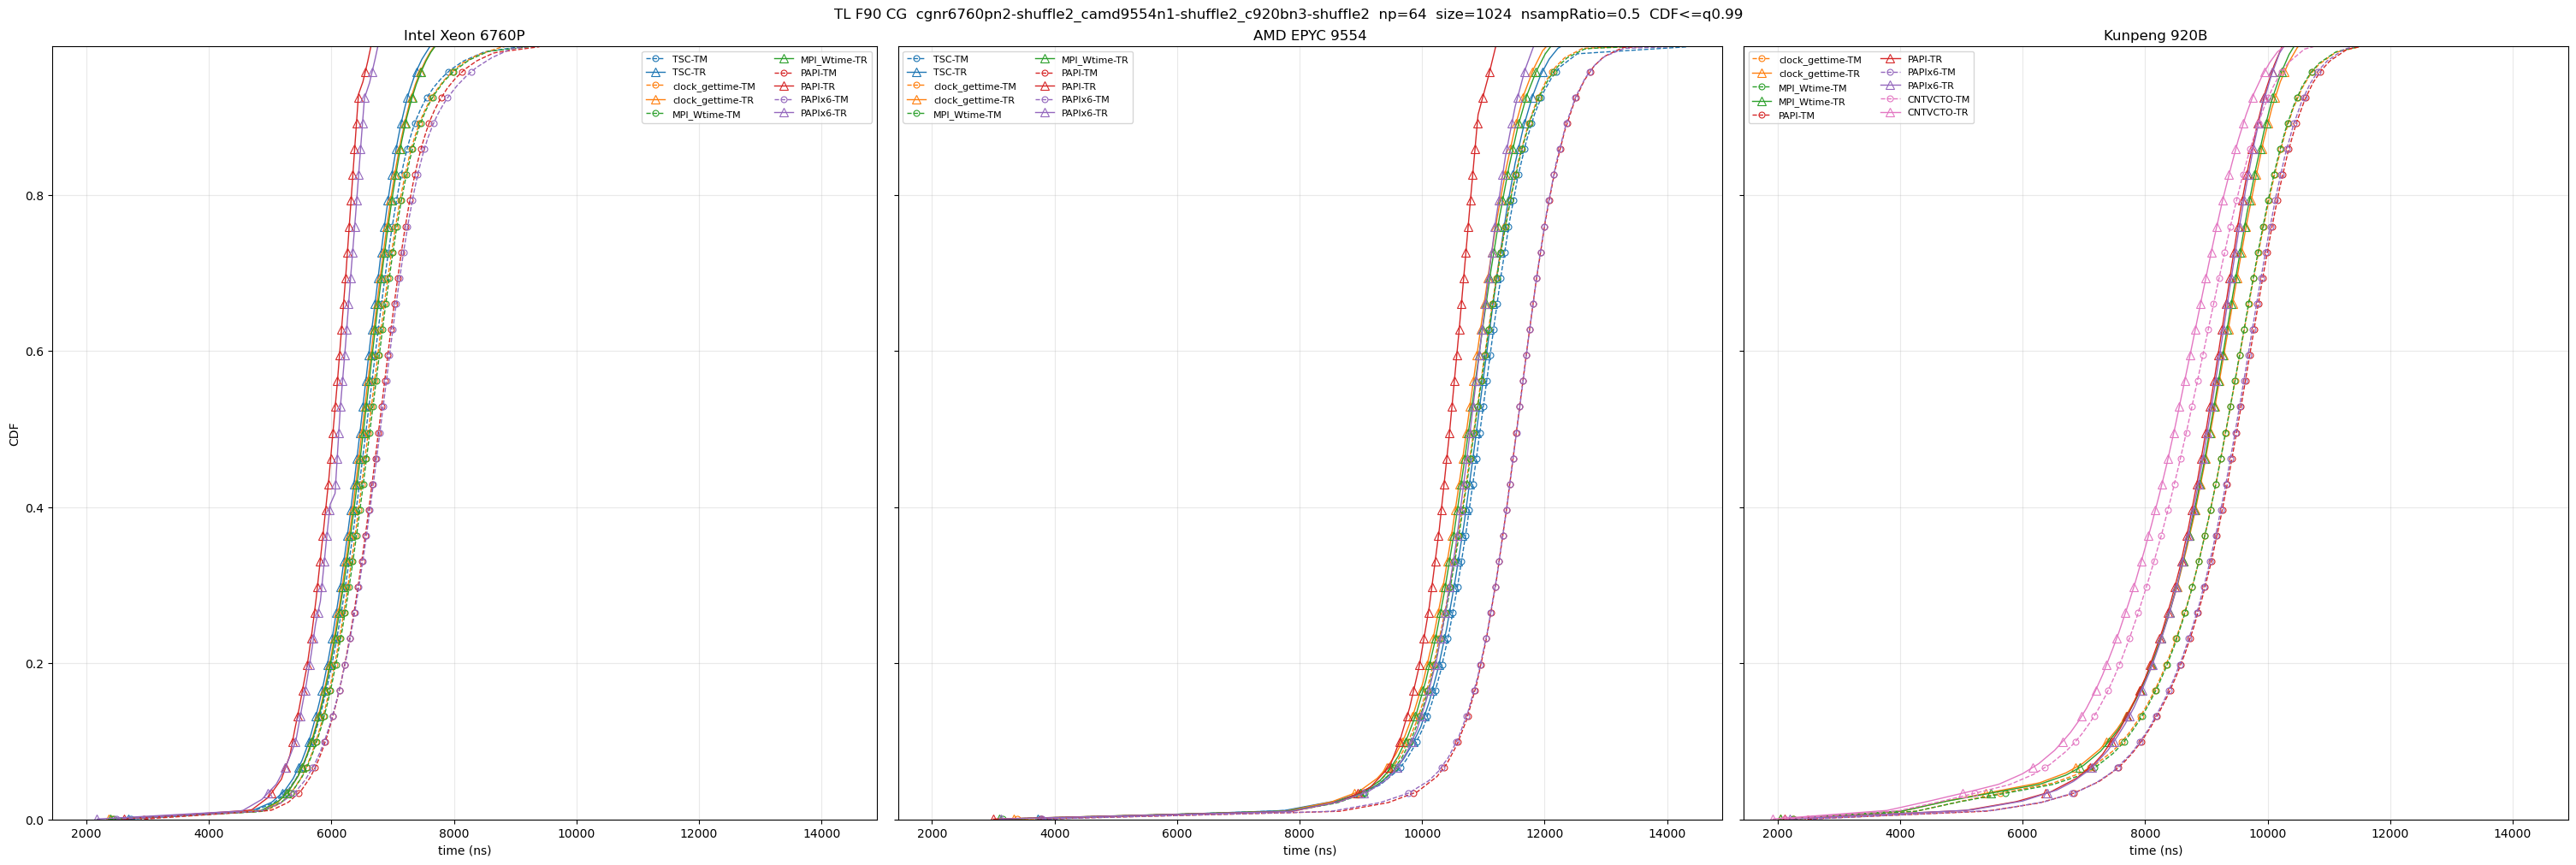

/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub/tl_f90_cg_calc_w_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size2048_ratio0.5_tm_tr_by_host.png


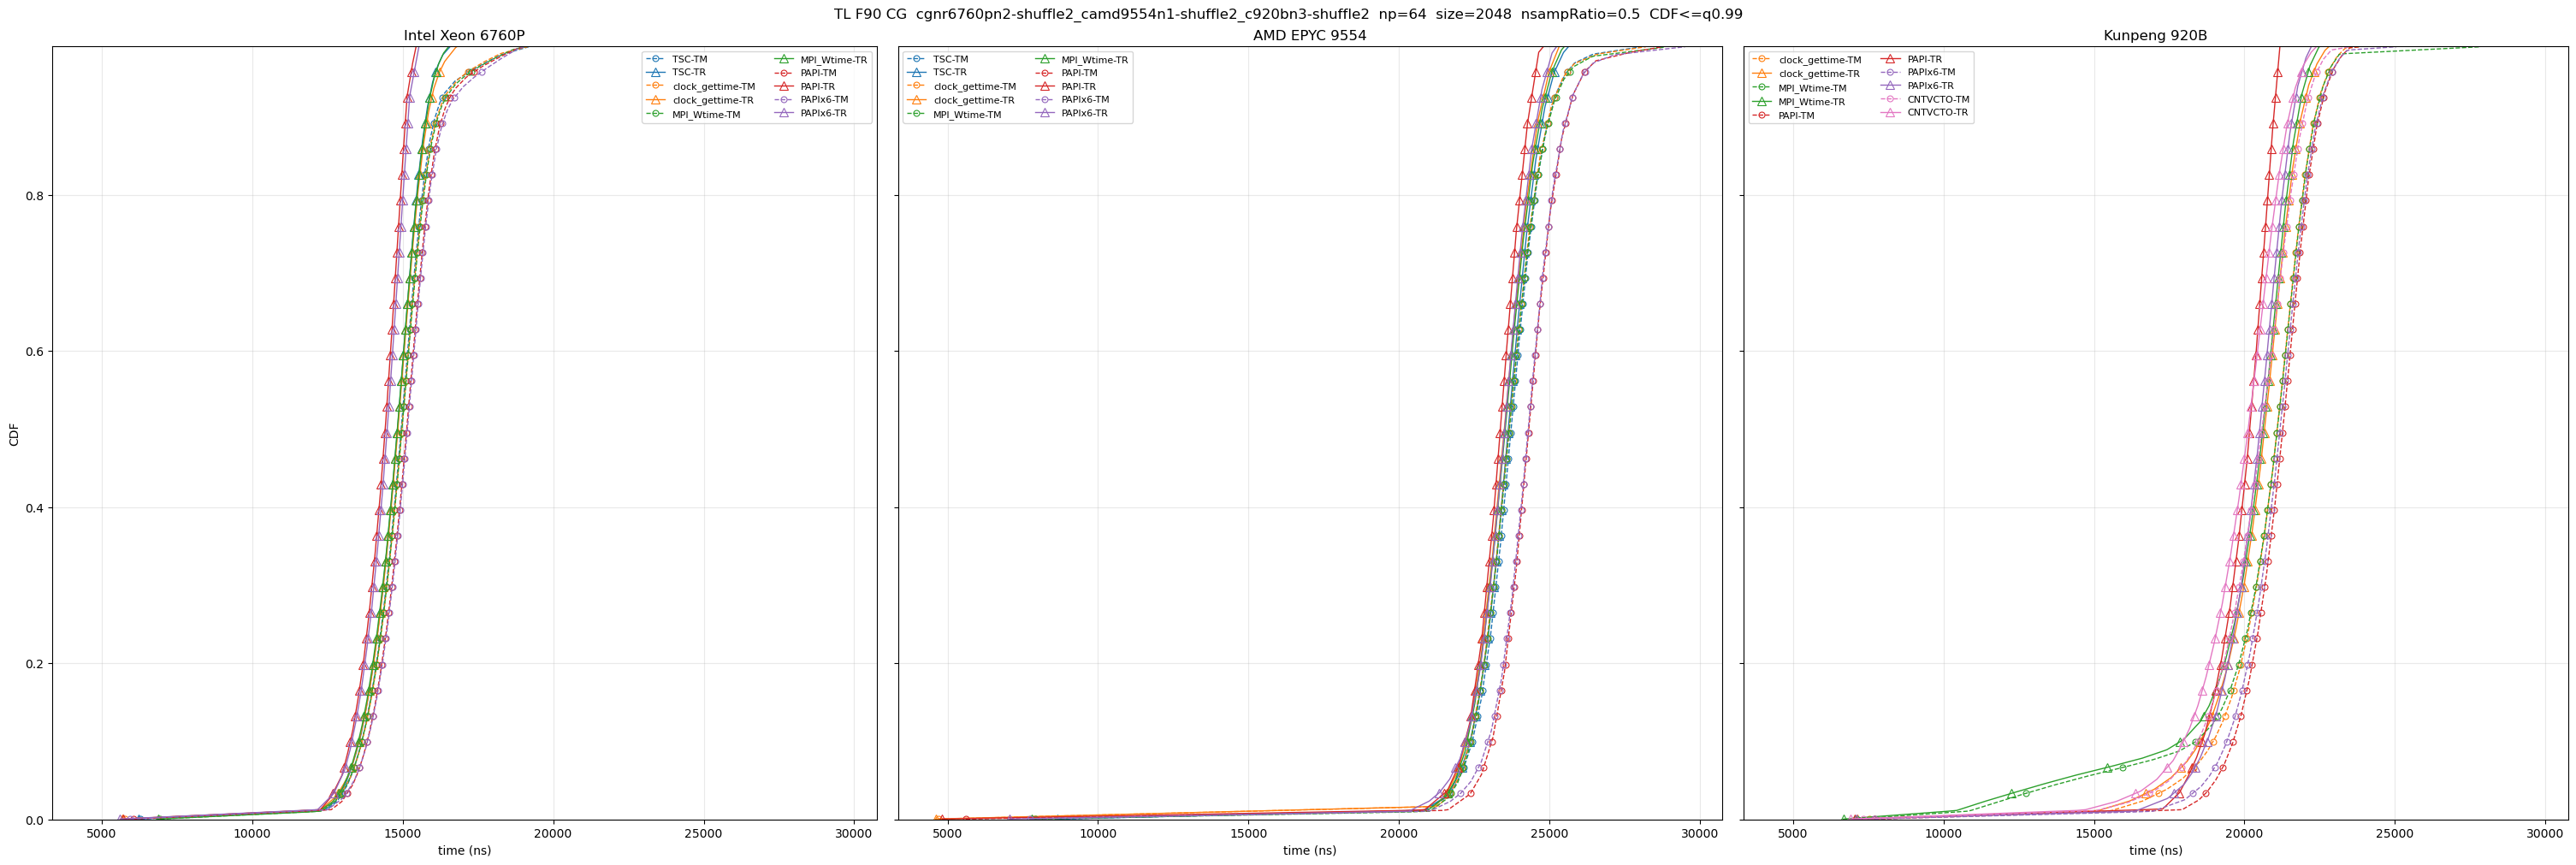

In [8]:
plot_df = df[df['timer'] != 'likwid'].copy()

if plot_df.empty:
    raise RuntimeError('No entries with tr_seq/tm_seq to plot')

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]


def seq_ecdf(seq):
    """ECDF (x, y) from a sample array, clipped to QUANTILE_DROP."""
    s = np.sort(np.asarray(seq, dtype=float))
    n = s.size
    if n == 0:
        return s, s
    y = (np.arange(n) + 0.5) / n
    keep = y <= QUANTILE_DROP
    return s[keep], y[keep]


for (kernel, np_val, size, nsamp_ratio), group_all in plot_df.groupby(['kernel', 'np', 'size', 'nsampRatio'], sort=True):
    fig, axes = plt.subplots(1, len(hosts), figsize=(10.0 * len(hosts), 10), sharey=True, constrained_layout=True)
    if len(hosts) == 1:
        axes = [axes]

    for ax, host in zip(axes, hosts):
        group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))

        for _, row in group.iterrows():
            timer = row['timer']
            color = TIMER_COLORS.get(timer)
            label = timer_label(timer)

            if row['tm_seq'] is None or row['tr_seq'] is None:
                continue

            tm_x, tm_y = seq_ecdf(row['tm_seq'])
            tr_x, tr_y = seq_ecdf(row['tr_seq'])

            tm_me = max(1, len(tm_x) // 30)
            tr_me = max(1, len(tr_x) // 30)

            ax.plot(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, marker='.', markevery=tm_me, markersize=10, markerfacecolor='none', markeredgewidth=0.8)
            ax.plot(tr_x, tr_y, label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0, marker='^', markevery=tr_me, markersize=7, markerfacecolor='none', markeredgewidth=0.8)

        ax.set_title(f"{HOST_LABELS.get(host, host)}")
        ax.set_xlabel('time (ns)')
        ax.set_ylim(0, QUANTILE_DROP)
        ax.grid(True, alpha=0.28)
        ax.legend(ncol=2, fontsize=8)

    xlims = [ax.get_xlim() for ax in axes]
    xlim = (min(lo for lo, hi in xlims), max(hi for lo, hi in xlims))
    for ax in axes:
        ax.set_xlim(xlim)
        ax.set_ylim(0, QUANTILE_DROP)

    axes[0].set_ylabel('CDF')
    fig.suptitle(f'{KERNEL_LABELS.get(kernel, kernel)}  {SHUFFLE_LABEL}  np={np_val}  size={size}  nsampRatio={nsamp_ratio}  CDF<=q{QUANTILE_DROP}')

    if SAVE_FIG:
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_np{np_val}_size{size}_ratio{nsamp_ratio}_tm_tr_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()
